APPLIED MACHINE LEARNING PROJECT - LOAN DEFAULT PREDICTION

📊 DATASET OVERVIEW
--------------------------------------------------
Dataset Shape: (9999, 35)
Rows: 9999, Columns: 35

Column Names (35):
 1. ID
 2. Loan Amount
 3. Funded Amount
 4. Funded Amount Investor
 5. Term
 6. Batch Enrolled
 7. Interest Rate
 8. Grade
 9. Sub Grade
10. Employment Duration
11. Home Ownership
12. Verification Status
13. Payment Plan
14. Loan Title
15. Debit to Income
16. Delinquency - two years
17. Inquires - six months
18. Open Account
19. Public Record
20. Revolving Balance
21. Revolving Utilities
22. Total Accounts
23. Initial List Status
24. Total Received Interest
25. Total Received Late Fee
26. Recoveries
27. Collection Recovery Fee
28. Collection 12 months Medical
29. Application Type
30. Last week Pay
31. Accounts Delinquent
32. Total Collection Amount
33. Total Current Balance
34. Total Revolving Credit Limit
35. Loan Status

📋 First 5 rows:
         ID  Loan Amount  Funded Amount  Funded Am

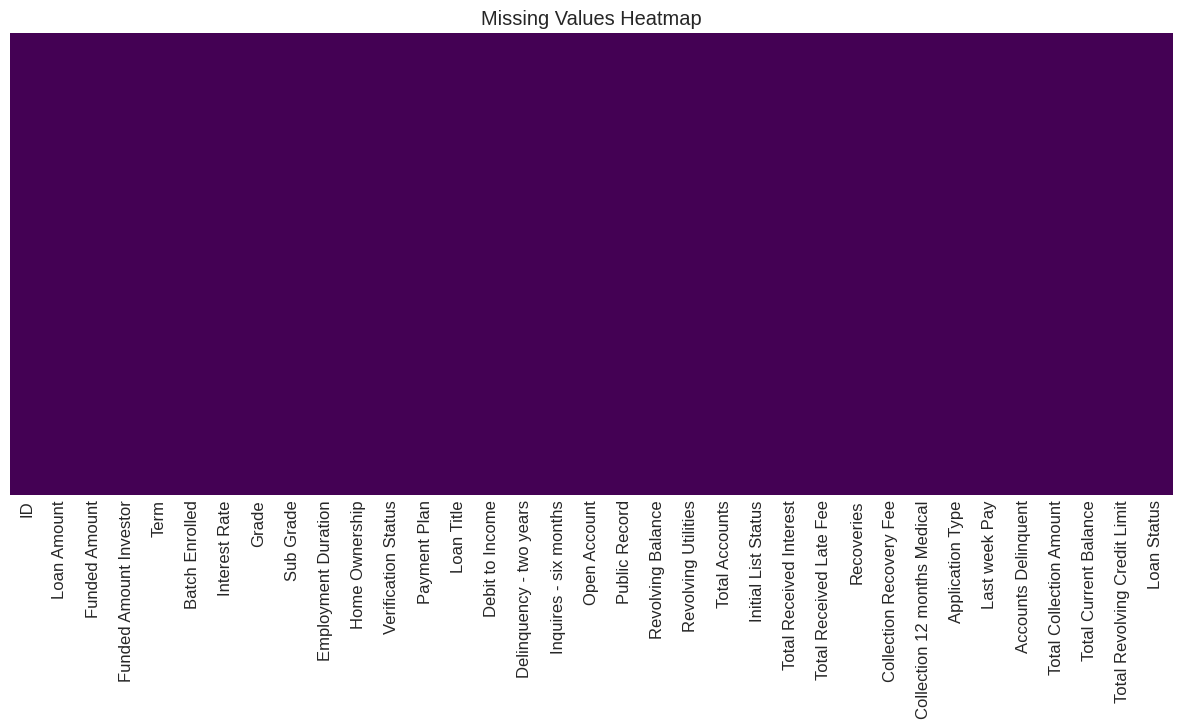


1.3 TARGET VARIABLE ANALYSIS
----------------------------------------
Target Variable: Loan Status
Distribution:
Loan Status
0    8994
1    1005
Name: count, dtype: int64
Percentage:
Loan Status
0    89.948995
1    10.051005
Name: count, dtype: float64


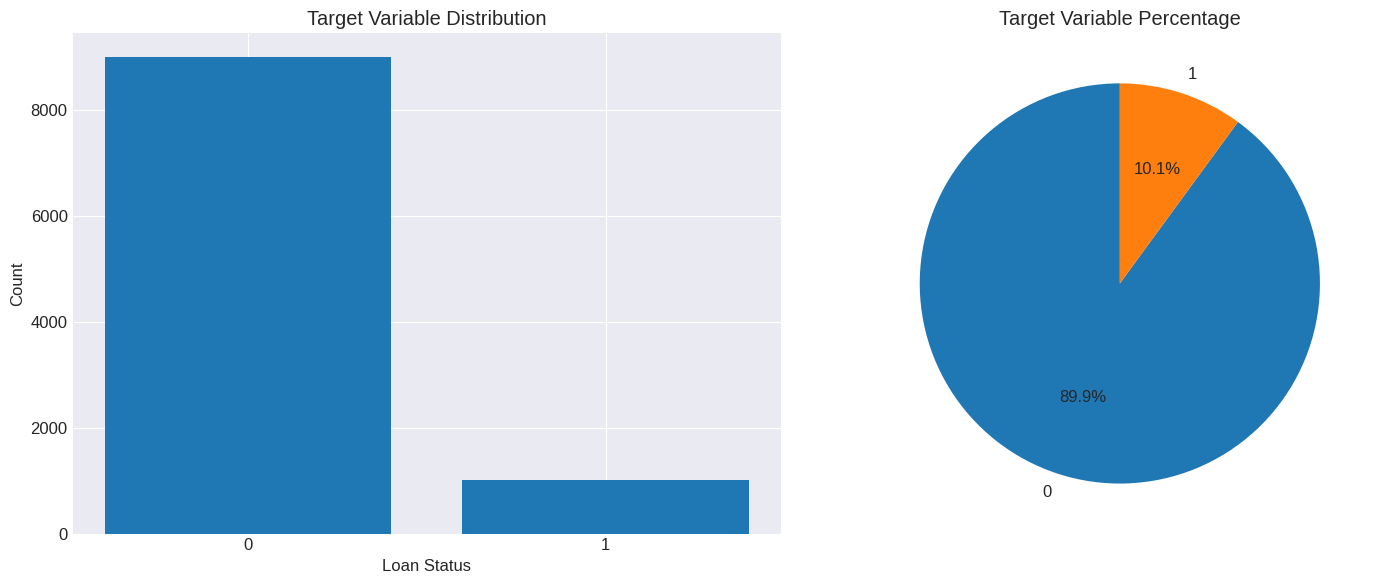

Class Imbalance Ratio: 0.112
⚠️ Significant class imbalance detected!

1.4 FEATURE DISTRIBUTIONS
----------------------------------------
Number of numerical features: 25


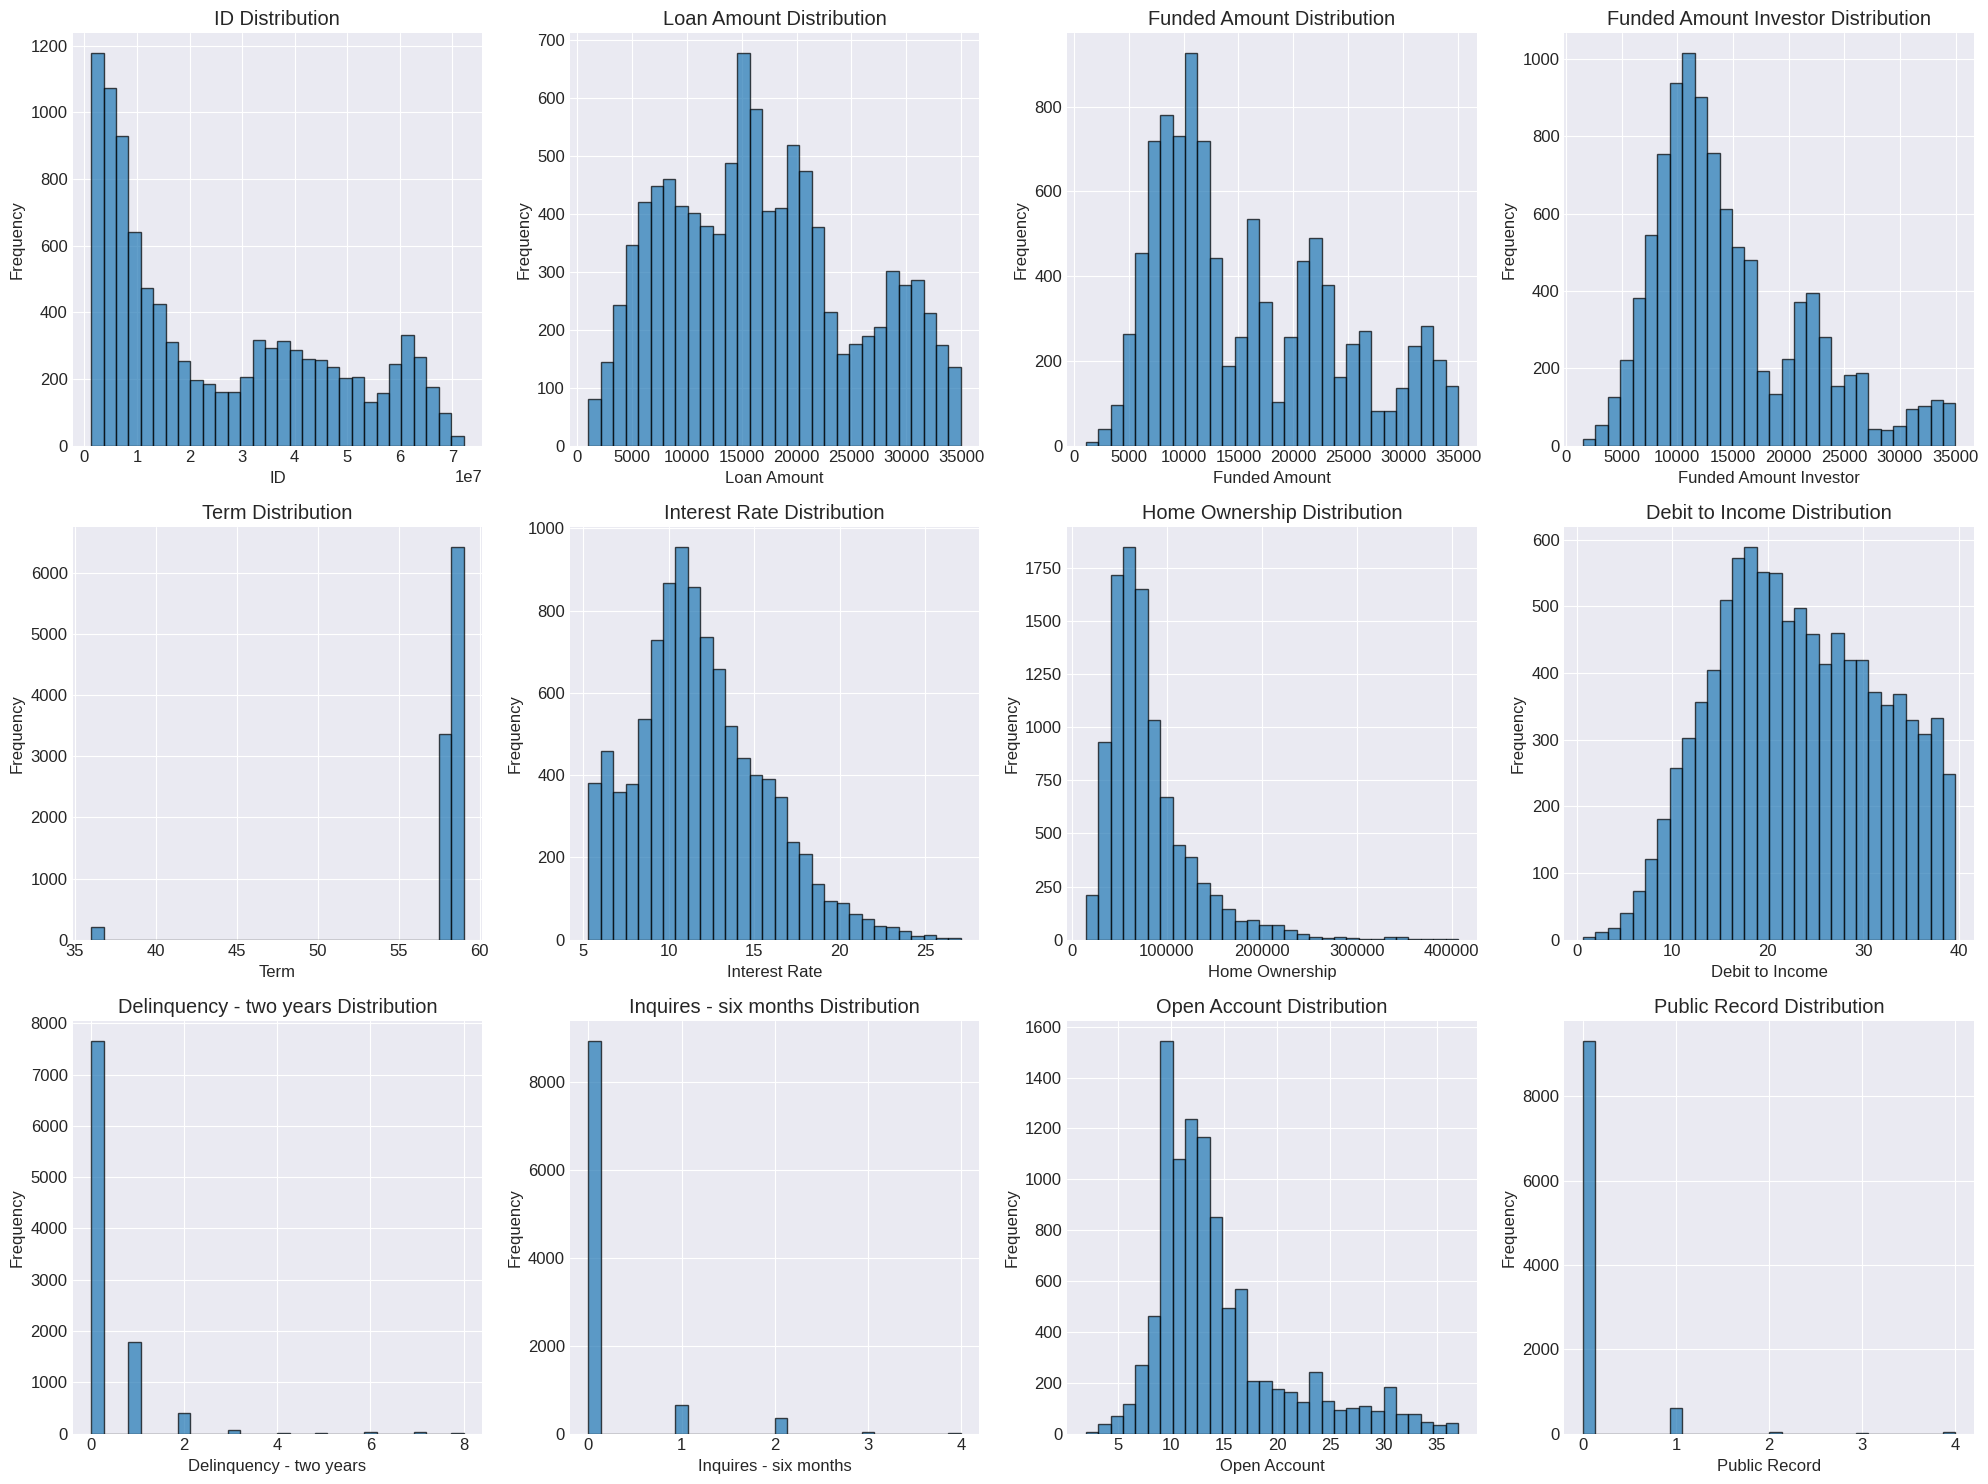


1.5 CORRELATION ANALYSIS
----------------------------------------


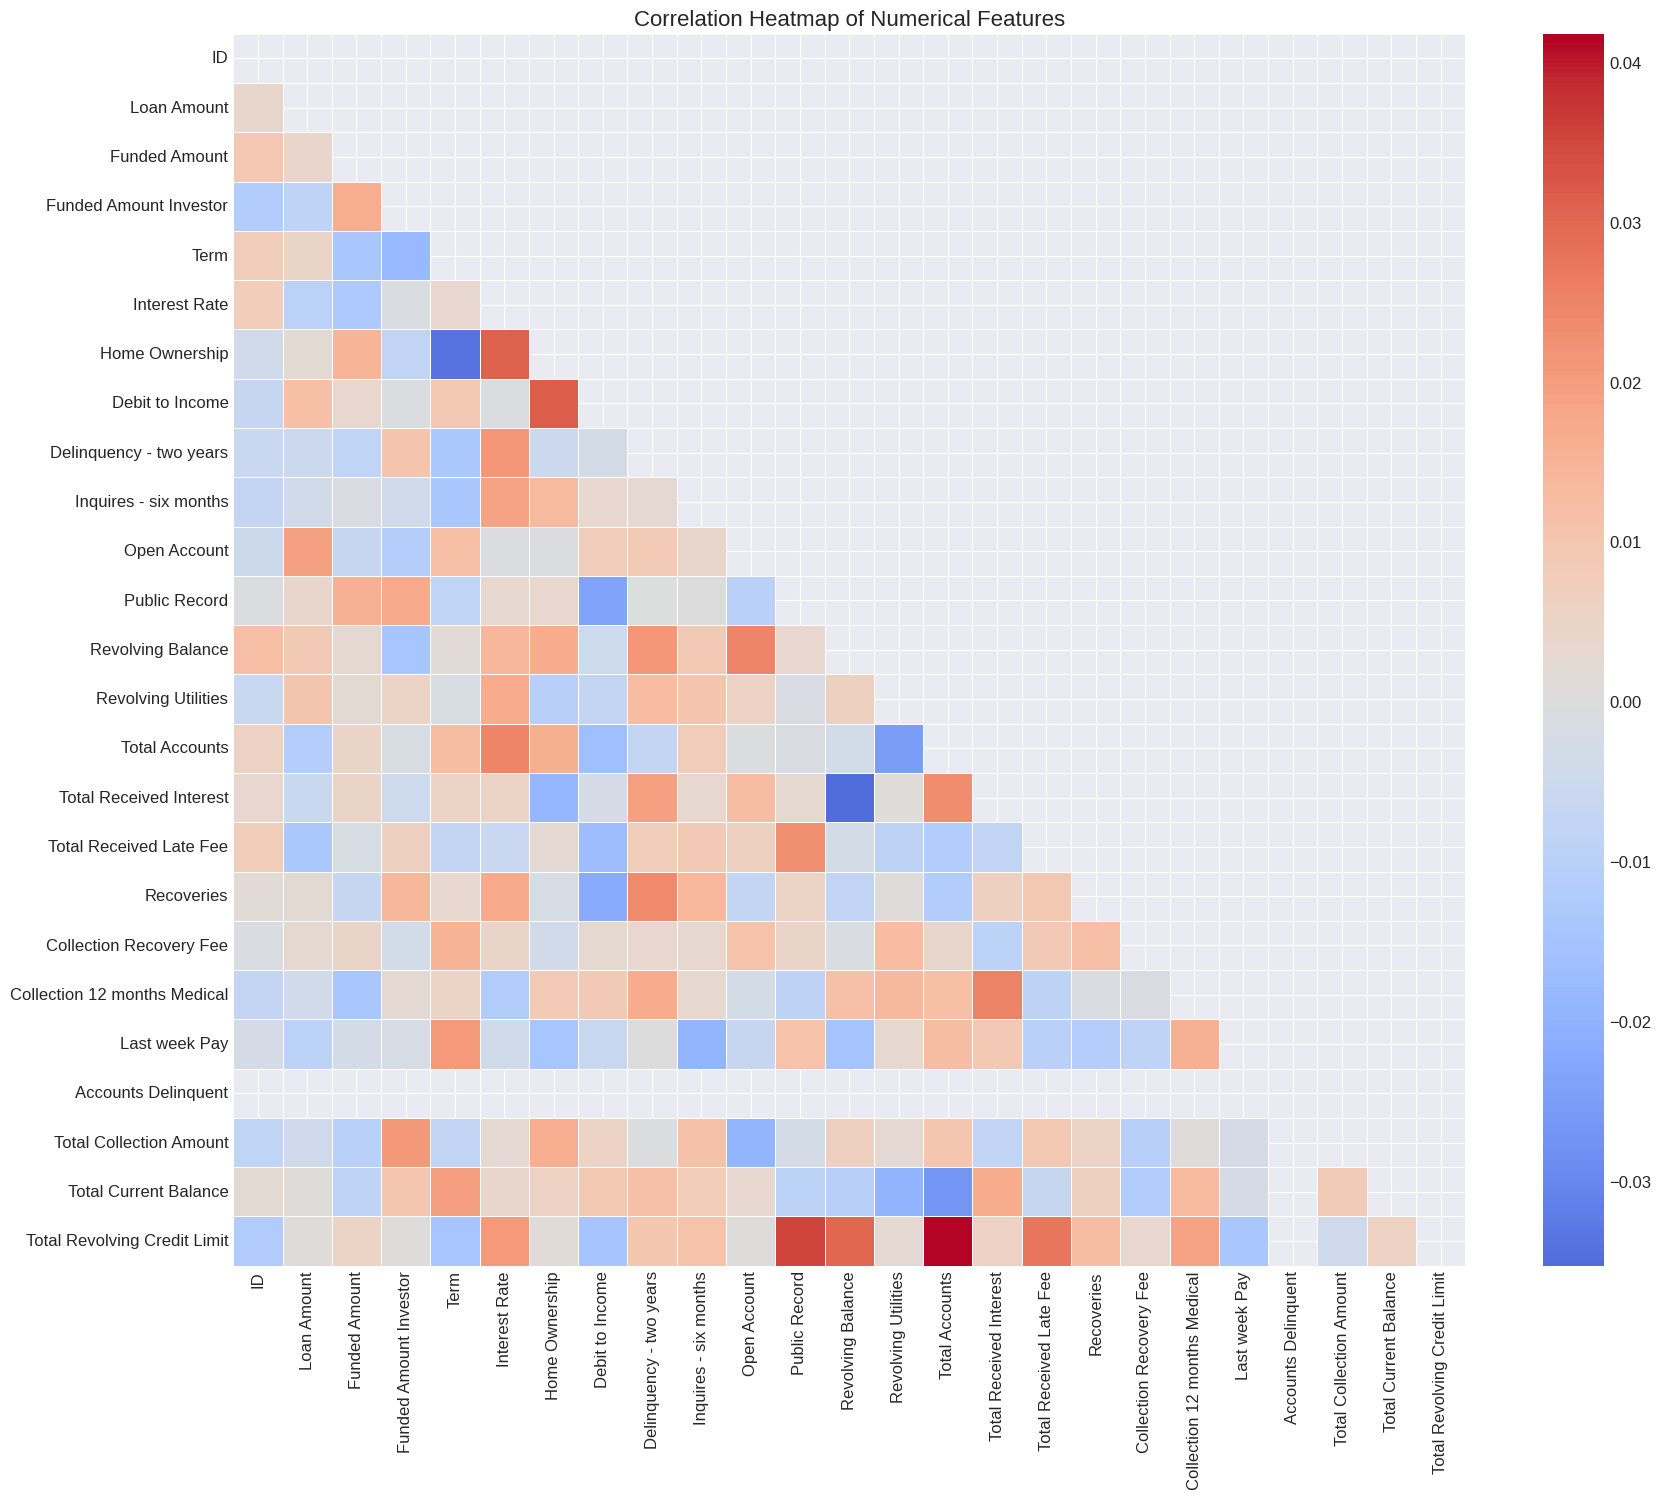


Number of highly correlated pairs (|r| > 0.7): 0

1.6 OUTLIER DETECTION
----------------------------------------
Outlier detection (Z-score > 3):
                         Outlier Count  Percentage
Inquires - six months              404    4.040404
Term                               211    2.110211
Home Ownership                     185    1.850185
Delinquency - two years            158    1.580158
Interest Rate                       66    0.660066
ID                                   0    0.000000
Loan Amount                          0    0.000000
Funded Amount Investor               0    0.000000
Funded Amount                        0    0.000000
Debit to Income                      0    0.000000


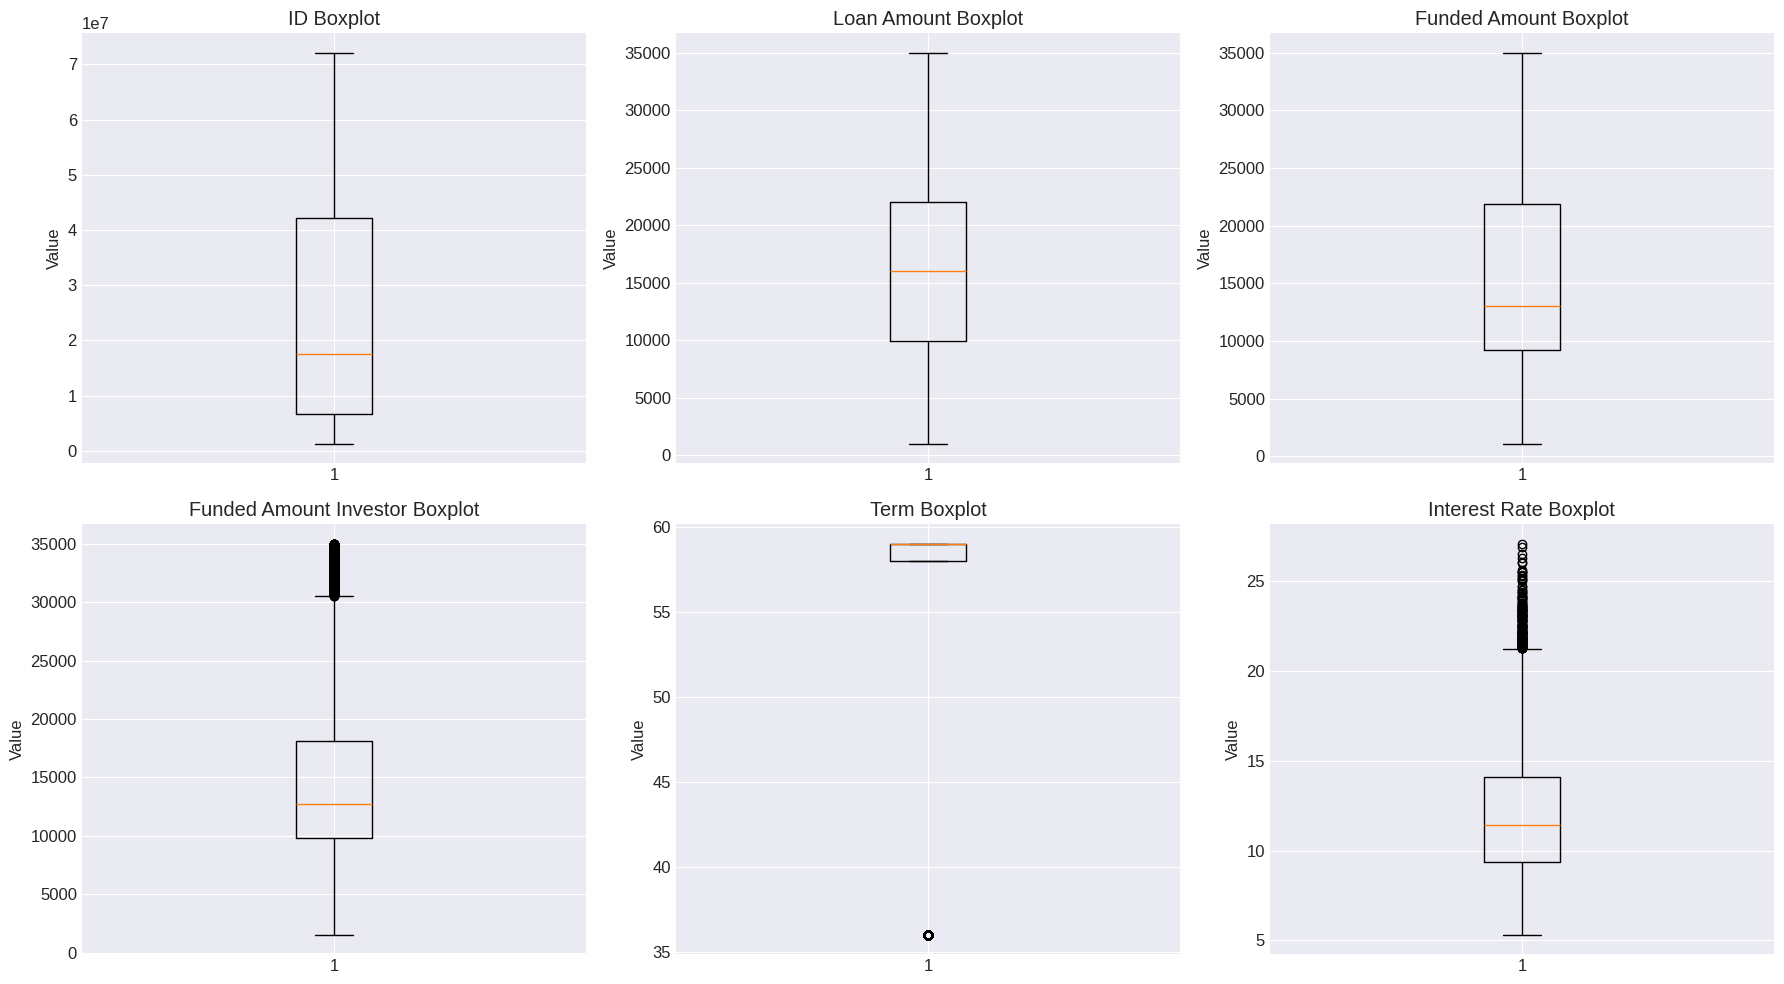


1.7 CATEGORICAL FEATURE ANALYSIS
----------------------------------------
Categorical features: ['Batch Enrolled', 'Grade', 'Sub Grade', 'Employment Duration', 'Verification Status', 'Payment Plan', 'Loan Title', 'Initial List Status', 'Application Type']


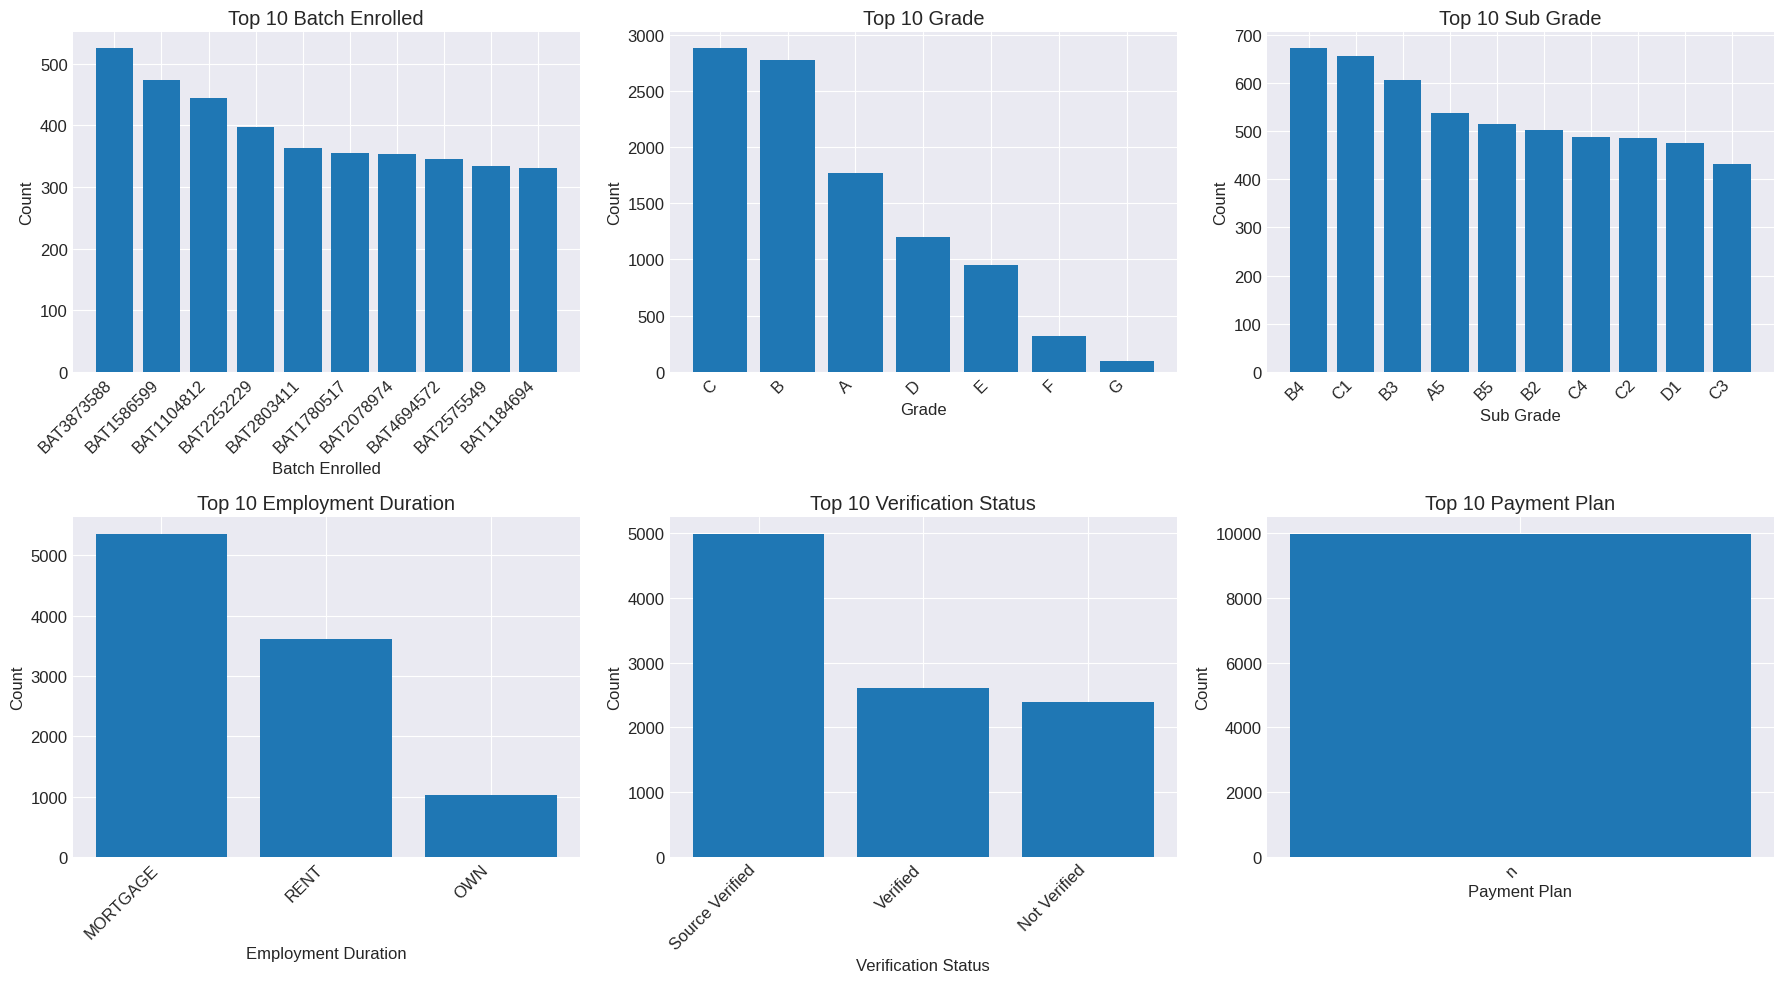

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Core ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
                           accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, confusion_matrix, classification_report,
                           mean_squared_error, mean_absolute_error, r2_score,
                           silhouette_score, davies_bouldin_score, roc_curve, precision_recall_curve
)

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Advanced
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from scipy import stats
import statsmodels.api as sm
from scipy.spatial.distance import cdist
import umap.umap_ as umap

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


# 3. LOAD DATASET

print("=" * 80)
print("APPLIED MACHINE LEARNING PROJECT - LOAN DEFAULT PREDICTION")
print("=" * 80)

# Load the dataset
df = pd.read_csv('ML_dataset.csv')

print("\n📊 DATASET OVERVIEW")
print("-" * 50)
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nColumn Names ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

# Display sample
print("\n📋 First 5 rows:")
print(df.head())
print("\n📋 Last 5 rows:")
print(df.tail())


#  EXPLORATORY DATA ANALYSIS (EDA)

print("\n" + "=" * 80)
print("TASK 1: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# 1.1 Basic Statistics
print("\n1.1 BASIC STATISTICS")
print("-" * 40)
print("Dataset Information:")
print(df.info())

print("\nDescriptive Statistics (Numerical):")
print(df.describe())

print("\nDescriptive Statistics (Categorical):")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Top 5: {df[col].value_counts().head()}")

# 1.2 Missing Values Analysis
print("\n1.2 MISSING VALUES ANALYSIS")
print("-" * 40)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values('Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("✅ No missing values found!")
else:
    print(f"⚠️ Total missing values: {missing_df['Missing Values'].sum()}")

# Visualize missing values
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

# 1.3 Target Variable Analysis
print("\n1.3 TARGET VARIABLE ANALYSIS")
print("-" * 40)
target_col = 'Loan Status'  # Assuming this is the target
if target_col in df.columns:
    target_counts = df[target_col].value_counts()
    target_percentage = (target_counts / len(df)) * 100

    print(f"Target Variable: {target_col}")
    print(f"Distribution:\n{target_counts}")
    print(f"Percentage:\n{target_percentage}")

    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].bar(target_counts.index.astype(str), target_counts.values)
    axes[0].set_title('Target Variable Distribution')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Count')

    axes[1].pie(target_counts.values, labels=target_counts.index.astype(str),
               autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Target Variable Percentage')

    plt.tight_layout()
    plt.show()

    # Check for class imbalance
    imbalance_ratio = target_counts.min() / target_counts.max()
    print(f"Class Imbalance Ratio: {imbalance_ratio:.3f}")
    if imbalance_ratio < 0.5:
        print("⚠️ Significant class imbalance detected!")

# 1.4 Feature Distributions
print("\n1.4 FEATURE DISTRIBUTIONS")
print("-" * 40)

# Select numerical columns for visualization
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"Number of numerical features: {len(numerical_cols)}")

# Plot distributions of top 12 numerical features
if len(numerical_cols) > 0:
    n_cols = min(12, len(numerical_cols))
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.ravel()

    for idx, col in enumerate(numerical_cols[:n_cols]):
        axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

    # Hide unused subplots
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# 1.5 Correlation Analysis
print("\n1.5 CORRELATION ANALYSIS")
print("-" * 40)

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=.5, annot=False, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nNumber of highly correlated pairs (|r| > 0.7): {len(high_corr_pairs)}")
if high_corr_pairs:
    print("Top 10 highly correlated feature pairs:")
    for i, (f1, f2, corr) in enumerate(high_corr_pairs[:10], 1):
        print(f"{i:2}. {f1} ↔ {f2}: {corr:.3f}")

# 1.6 Outlier Detection
print("\n1.6 OUTLIER DETECTION")
print("-" * 40)

def detect_outliers_zscore(data, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)

# Check outliers in numerical columns
if len(numerical_cols) > 0:
    outlier_counts = {}
    for col in numerical_cols[:10]:  # Check first 10 columns
        outliers = detect_outliers_zscore(df[col].dropna().values)
        outlier_counts[col] = len(outliers[0])

    outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
    outlier_df['Percentage'] = (outlier_df['Outlier Count'] / len(df)) * 100
    print("Outlier detection (Z-score > 3):")
    print(outlier_df.sort_values('Outlier Count', ascending=False))

    # Visualize outliers with boxplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for idx, col in enumerate(numerical_cols[:6]):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col} Boxplot')
        axes[idx].set_ylabel('Value')

    plt.tight_layout()
    plt.show()

# 1.7 Categorical Analysis
print("\n1.7 CATEGORICAL FEATURE ANALYSIS")
print("-" * 40)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    print(f"Categorical features: {categorical_cols}")

    # Plot categorical distributions
    n_cats = min(6, len(categorical_cols))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for idx, col in enumerate(categorical_cols[:n_cats]):
        top_cats = df[col].value_counts().head(10)
        axes[idx].bar(range(len(top_cats)), top_cats.values)
        axes[idx].set_title(f'Top 10 {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(len(top_cats)))
        axes[idx].set_xticklabels(top_cats.index, rotation=45, ha='right')

    # Hide unused subplots
    for idx in range(n_cats, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()


HYPOTHESIS FORMULATION, COST FUNCTION & GRADIENT DESCENT

2.1 HYPOTHESIS FORMULATION
----------------------------------------

2.2 PREPARING DATA FOR FROM-SCRATCH IMPLEMENTATIONS
----------------------------------------
Features selected: ['Interest Rate', 'Debit to Income', 'Loan Amount']
X shape: (9999, 4)
y shape: (9999,)

2.3 COST FUNCTION IMPLEMENTATION (FROM SCRATCH)
----------------------------------------
Testing cost functions...
MSE: 0.0250
Log Loss: 0.1643

2.4 GRADIENT DESCENT IMPLEMENTATION (FROM SCRATCH)
----------------------------------------

Running Gradient Descent for Linear Regression...
Iteration 0: Cost = 3.033529
Iteration 100: Cost = 0.477332
Iteration 200: Cost = 0.141300
Iteration 300: Cost = 0.097102
Iteration 400: Cost = 0.091286

Running Gradient Descent for Logistic Regression...
Iteration 0: Cost = 0.924467
Iteration 100: Cost = 0.342805
Iteration 200: Cost = 0.327813
Iteration 300: Cost = 0.326407
Iteration 400: Cost = 0.326215


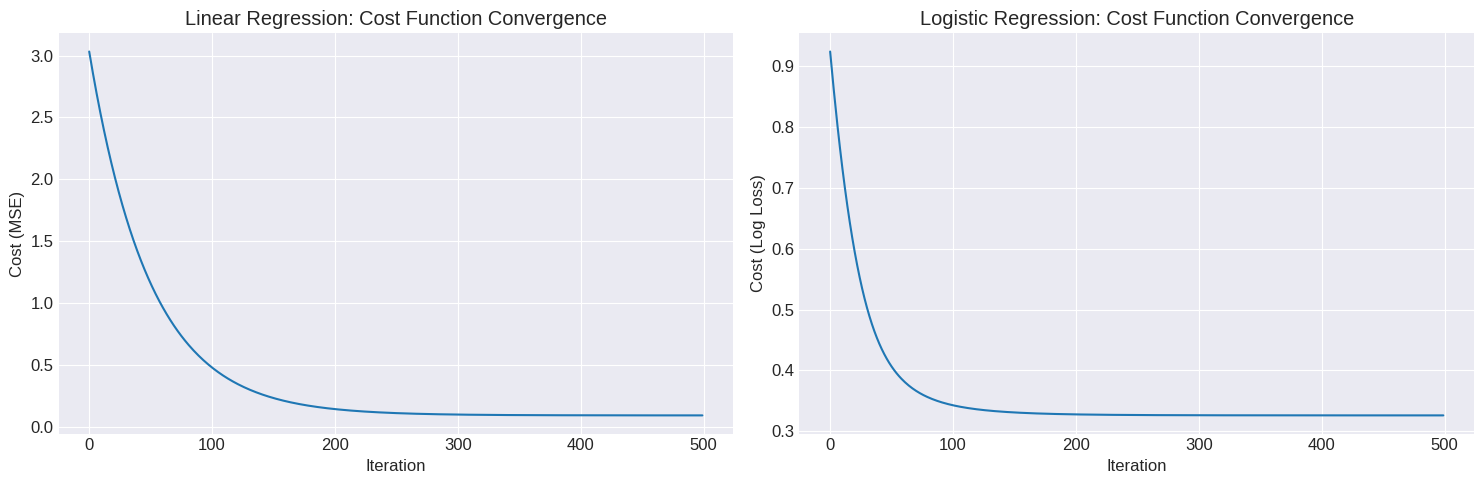


Final Linear Regression Parameters: [0.1031133  0.00118258 0.00257234 0.01015869]
Final Logistic Regression Parameters: [-2.18302476  0.01634712 -0.00586169  0.00703844]


In [5]:

# HYPOTHESIS, COST FUNCTION & GRADIENT DESCENT

print("\n" + "=" * 80)
print("HYPOTHESIS FORMULATION, COST FUNCTION & GRADIENT DESCENT")
print("=" * 80)

# 2.1 Hypothesis Formulation
print("\n2.1 HYPOTHESIS FORMULATION")
print("-" * 40)


# 2.2 Prepare Data for From-Scratch Implementation
print("\n2.2 PREPARING DATA FOR FROM-SCRATCH IMPLEMENTATIONS")
print("-" * 40)

# Select features for demonstration
features_for_demo = ['Interest Rate', 'Debit to Income', 'Loan Amount']
if all(col in df.columns for col in features_for_demo):
    X_demo = df[features_for_demo].fillna(df[features_for_demo].median())
    y_demo = df[target_col] if target_col in df.columns else df.iloc[:, -1]

    # Normalize features
    scaler = StandardScaler()
    X_demo_scaled = scaler.fit_transform(X_demo)

    # Add bias term
    X_demo_bias = np.c_[np.ones((X_demo_scaled.shape[0], 1)), X_demo_scaled]

    print(f"Features selected: {features_for_demo}")
    print(f"X shape: {X_demo_bias.shape}")
    print(f"y shape: {y_demo.shape}")
else:
    print("Required features not found in dataset")
    # Use first few numerical columns
    demo_cols = numerical_cols[:3] if len(numerical_cols) >= 3 else numerical_cols
    X_demo = df[demo_cols].fillna(df[demo_cols].median())
    y_demo = df[target_col] if target_col in df.columns else df.iloc[:, -1]
    scaler = StandardScaler()
    X_demo_scaled = scaler.fit_transform(X_demo)
    X_demo_bias = np.c_[np.ones((X_demo_scaled.shape[0], 1)), X_demo_scaled]
    print(f"Using features: {demo_cols}")

# 2.3 Cost Function Implementation (From Scratch)
print("\n2.3 COST FUNCTION IMPLEMENTATION (FROM SCRATCH)")
print("-" * 40)

def mean_squared_error_scratch(y_true, y_pred):
    """Mean Squared Error cost function from scratch"""
    return np.mean((y_true - y_pred) ** 2)

def logistic_cost_scratch(y_true, y_pred):
    """Logistic regression cost function from scratch"""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def linear_hypothesis(X, theta):
    """Linear hypothesis function"""
    return X.dot(theta)

def sigmoid(z):
    """Sigmoid function"""
    return 1 / (1 + np.exp(-z))

def logistic_hypothesis(X, theta):
    """Logistic hypothesis function"""
    return sigmoid(X.dot(theta))

# Test cost functions
print("Testing cost functions...")
np.random.seed(42)
test_y_true = np.array([0, 1, 0, 1])
test_y_pred = np.array([0.1, 0.9, 0.2, 0.8])

mse = mean_squared_error_scratch(test_y_true, test_y_pred)
log_loss = logistic_cost_scratch(test_y_true, test_y_pred)

print(f"MSE: {mse:.4f}")
print(f"Log Loss: {log_loss:.4f}")

# 2.4 Gradient Descent Implementation (From Scratch)
print("\n2.4 GRADIENT DESCENT IMPLEMENTATION (FROM SCRATCH)")
print("-" * 40)

def gradient_descent_linear(X, y, theta, alpha, iterations):
    """Gradient descent for linear regression (from scratch)"""
    m = len(y)
    cost_history = []

    for i in range(iterations):
        # Calculate predictions
        predictions = X.dot(theta)

        # Calculate error
        errors = predictions - y

        # Calculate gradient
        gradient = (1/m) * X.T.dot(errors)

        # Update parameters
        theta = theta - alpha * gradient

        # Calculate cost
        cost = mean_squared_error_scratch(y, predictions)
        cost_history.append(cost)

        # Print progress
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return theta, cost_history

def gradient_descent_logistic(X, y, theta, alpha, iterations):
    """Gradient descent for logistic regression (from scratch)"""
    m = len(y)
    cost_history = []

    for i in range(iterations):
        # Calculate predictions
        predictions = sigmoid(X.dot(theta))

        # Calculate gradient
        gradient = (1/m) * X.T.dot(predictions - y)

        # Update parameters
        theta = theta - alpha * gradient

        # Calculate cost
        cost = logistic_cost_scratch(y, predictions)
        cost_history.append(cost)

        # Print progress
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return theta, cost_history

# Run gradient descent
print("\nRunning Gradient Descent for Linear Regression...")
np.random.seed(42)
theta_init = np.random.randn(X_demo_bias.shape[1])
theta_linear, cost_history_linear = gradient_descent_linear(
    X_demo_bias, y_demo, theta_init, alpha=0.01, iterations=500
)

print("\nRunning Gradient Descent for Logistic Regression...")
theta_init = np.random.randn(X_demo_bias.shape[1])
# Convert to binary for logistic regression
y_binary = (y_demo > y_demo.median()).astype(int)
theta_logistic, cost_history_logistic = gradient_descent_logistic(
    X_demo_bias, y_binary, theta_init, alpha=0.1, iterations=500
)

# Plot cost history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(cost_history_linear)
axes[0].set_title('Linear Regression: Cost Function Convergence')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (MSE)')
axes[0].grid(True)

axes[1].plot(cost_history_logistic)
axes[1].set_title('Logistic Regression: Cost Function Convergence')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost (Log Loss)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Linear Regression Parameters: {theta_linear}")
print(f"Final Logistic Regression Parameters: {theta_logistic}")



 LINEAR REGRESSION

3.1 DATA PREPARATION FOR LINEAR REGRESSION
----------------------------------------
Regression Features: ['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Interest Rate', 'Home Ownership', 'Debit to Income']
X shape: (9999, 8), y shape: (9999,)

3.2 LINEAR REGRESSION FROM SCRATCH
----------------------------------------
Training Linear Regression from scratch...
Iteration 0: Cost = 198155007.286094
Iteration 100: Cost = 4477194.272463
Iteration 200: Cost = 1065244.814895
Iteration 300: Cost = 1005039.558154
Iteration 400: Cost = 1003975.254586
Iteration 500: Cost = 1003956.399174
Iteration 600: Cost = 1003956.064251
Iteration 700: Cost = 1003956.058283
Iteration 800: Cost = 1003956.058176
Iteration 900: Cost = 1003956.058174

From-Scratch Model Performance:
MSE: 1014428.4201
MAE: 802.2791
R² Score: 0.9317

3.3 LINEAR REGRESSION USING LIBRARY (scikit-learn)
----------------------------------------
Library Model Performance:
MSE: 1014428.4182


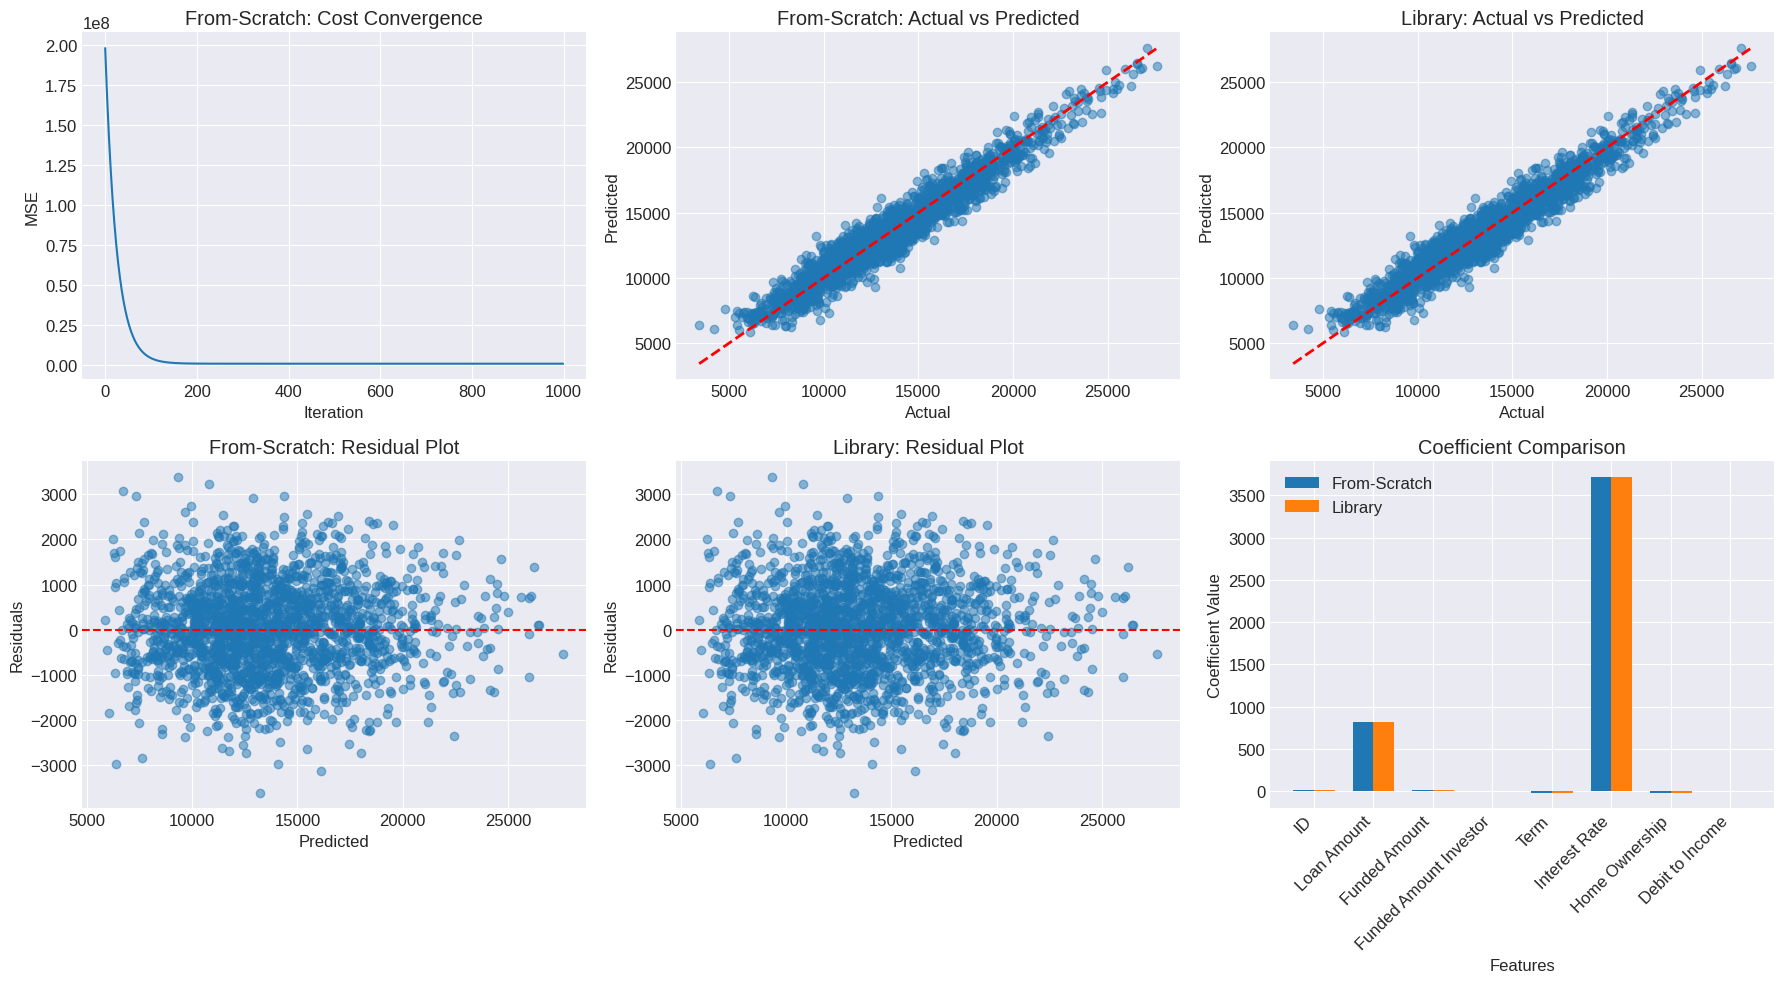

In [6]:

#  LINEAR REGRESSION

print("\n" + "=" * 80)
print(" LINEAR REGRESSION")
print("=" * 80)

# 3.1 Prepare Data for Linear Regression
print("\n3.1 DATA PREPARATION FOR LINEAR REGRESSION")
print("-" * 40)

# Create a continuous target for regression (if not already)
if target_col in df.columns and df[target_col].nunique() > 10:
    y_reg = df[target_col]
else:
    # Create synthetic continuous target based on features
    y_reg = df['Interest Rate'] * 1000 + df['Loan Amount'] * 0.1 + np.random.normal(0, 1000, len(df))

# Select features for regression
reg_features = [col for col in numerical_cols if col != target_col][:8]  # Use first 8 features
X_reg = df[reg_features].fillna(df[reg_features].median())

print(f"Regression Features: {reg_features}")
print(f"X shape: {X_reg.shape}, y shape: {y_reg.shape}")

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# 3.2 Linear Regression from Scratch
print("\n3.2 LINEAR REGRESSION FROM SCRATCH")
print("-" * 40)

class LinearRegressionScratch:
    """Linear Regression implementation from scratch"""

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        """Train the model using gradient descent"""
        # Add bias term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Initialize parameters
        m, n = X_b.shape
        self.theta = np.random.randn(n, 1)
        y = y.reshape(-1, 1)

        # Gradient descent
        for i in range(self.iterations):
            # Predictions
            predictions = X_b.dot(self.theta)

            # Errors
            errors = predictions - y

            # Gradient
            gradients = (2/m) * X_b.T.dot(errors)

            # Update parameters
            self.theta = self.theta - self.learning_rate * gradients

            # Calculate cost
            cost = np.mean(errors ** 2)
            self.cost_history.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.6f}")

        return self

    def predict(self, X):
        """Make predictions"""
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta).flatten()

    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

# Train from-scratch model
print("Training Linear Regression from scratch...")
lr_scratch = LinearRegressionScratch(learning_rate=0.01, iterations=1000)
lr_scratch.fit(X_train_reg_scaled, y_train_reg.values)

# Make predictions
y_pred_scratch = lr_scratch.predict(X_test_reg_scaled)

# Calculate metrics
mse_scratch = mean_squared_error(y_test_reg, y_pred_scratch)
mae_scratch = mean_absolute_error(y_test_reg, y_pred_scratch)
r2_scratch = r2_score(y_test_reg, y_pred_scratch)

print(f"\nFrom-Scratch Model Performance:")
print(f"MSE: {mse_scratch:.4f}")
print(f"MAE: {mae_scratch:.4f}")
print(f"R² Score: {r2_scratch:.4f}")

# 3.3 Linear Regression using Library
print("\n3.3 LINEAR REGRESSION USING LIBRARY (scikit-learn)")
print("-" * 40)

# Train library model
lr_library = LinearRegression()
lr_library.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_library = lr_library.predict(X_test_reg_scaled)

# Calculate metrics
mse_library = mean_squared_error(y_test_reg, y_pred_library)
mae_library = mean_absolute_error(y_test_reg, y_pred_library)
r2_library = r2_score(y_test_reg, y_pred_library)

print("Library Model Performance:")
print(f"MSE: {mse_library:.4f}")
print(f"MAE: {mae_library:.4f}")
print(f"R² Score: {r2_library:.4f}")

# 3.4 Compare Coefficients
print("\n3.4 COEFFICIENT COMPARISON")
print("-" * 40)

# Get coefficients
coeff_scratch = lr_scratch.theta.flatten()[1:]  # Exclude bias
coeff_library = lr_library.coef_

coeff_df = pd.DataFrame({
    'Feature': reg_features,
    'From_Scratch': coeff_scratch[:len(reg_features)],
    'Library': coeff_library
})

print("Coefficient Comparison:")
print(coeff_df)

# 3.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Cost convergence
axes[0, 0].plot(lr_scratch.cost_history)
axes[0, 0].set_title('From-Scratch: Cost Convergence')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].grid(True)

# Actual vs Predicted (Scratch)
axes[0, 1].scatter(y_test_reg, y_pred_scratch, alpha=0.5)
axes[0, 1].plot([y_test_reg.min(), y_test_reg.max()],
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0, 1].set_title('From-Scratch: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

# Actual vs Predicted (Library)
axes[0, 2].scatter(y_test_reg, y_pred_library, alpha=0.5)
axes[0, 2].plot([y_test_reg.min(), y_test_reg.max()],
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0, 2].set_title('Library: Actual vs Predicted')
axes[0, 2].set_xlabel('Actual')
axes[0, 2].set_ylabel('Predicted')

# Residuals (Scratch)
axes[1, 0].scatter(y_pred_scratch, y_test_reg - y_pred_scratch, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('From-Scratch: Residual Plot')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')

# Residuals (Library)
axes[1, 1].scatter(y_pred_library, y_test_reg - y_pred_library, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('Library: Residual Plot')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')

# Coefficient Comparison
x_pos = np.arange(len(reg_features))
width = 0.35
axes[1, 2].bar(x_pos - width/2, coeff_scratch, width, label='From-Scratch')
axes[1, 2].bar(x_pos + width/2, coeff_library, width, label='Library')
axes[1, 2].set_title('Coefficient Comparison')
axes[1, 2].set_xlabel('Features')
axes[1, 2].set_ylabel('Coefficient Value')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(reg_features, rotation=45, ha='right')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


 LOGISTIC REGRESSION

4.1 DATA PREPARATION FOR LOGISTIC REGRESSION
----------------------------------------
Classification Features: ['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Interest Rate', 'Home Ownership', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months']
Target distribution:
Loan Status
0    8994
1    1005
Name: count, dtype: int64

4.2 LOGISTIC REGRESSION FROM SCRATCH
----------------------------------------
Training Logistic Regression from scratch...
Iteration 0: Cost = 1.126950
Iteration 100: Cost = 0.384266
Iteration 200: Cost = 0.334274
Converged at iteration 220

From-Scratch Model Performance:
Accuracy: 0.8995
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.4947

4.3 LOGISTIC REGRESSION USING LIBRARY
----------------------------------------
Library Model Performance:
Accuracy: 0.8995
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.4889

4.4 THRESHOLD ANALYSIS AND PROBABILITY INTERPRETATION
-----

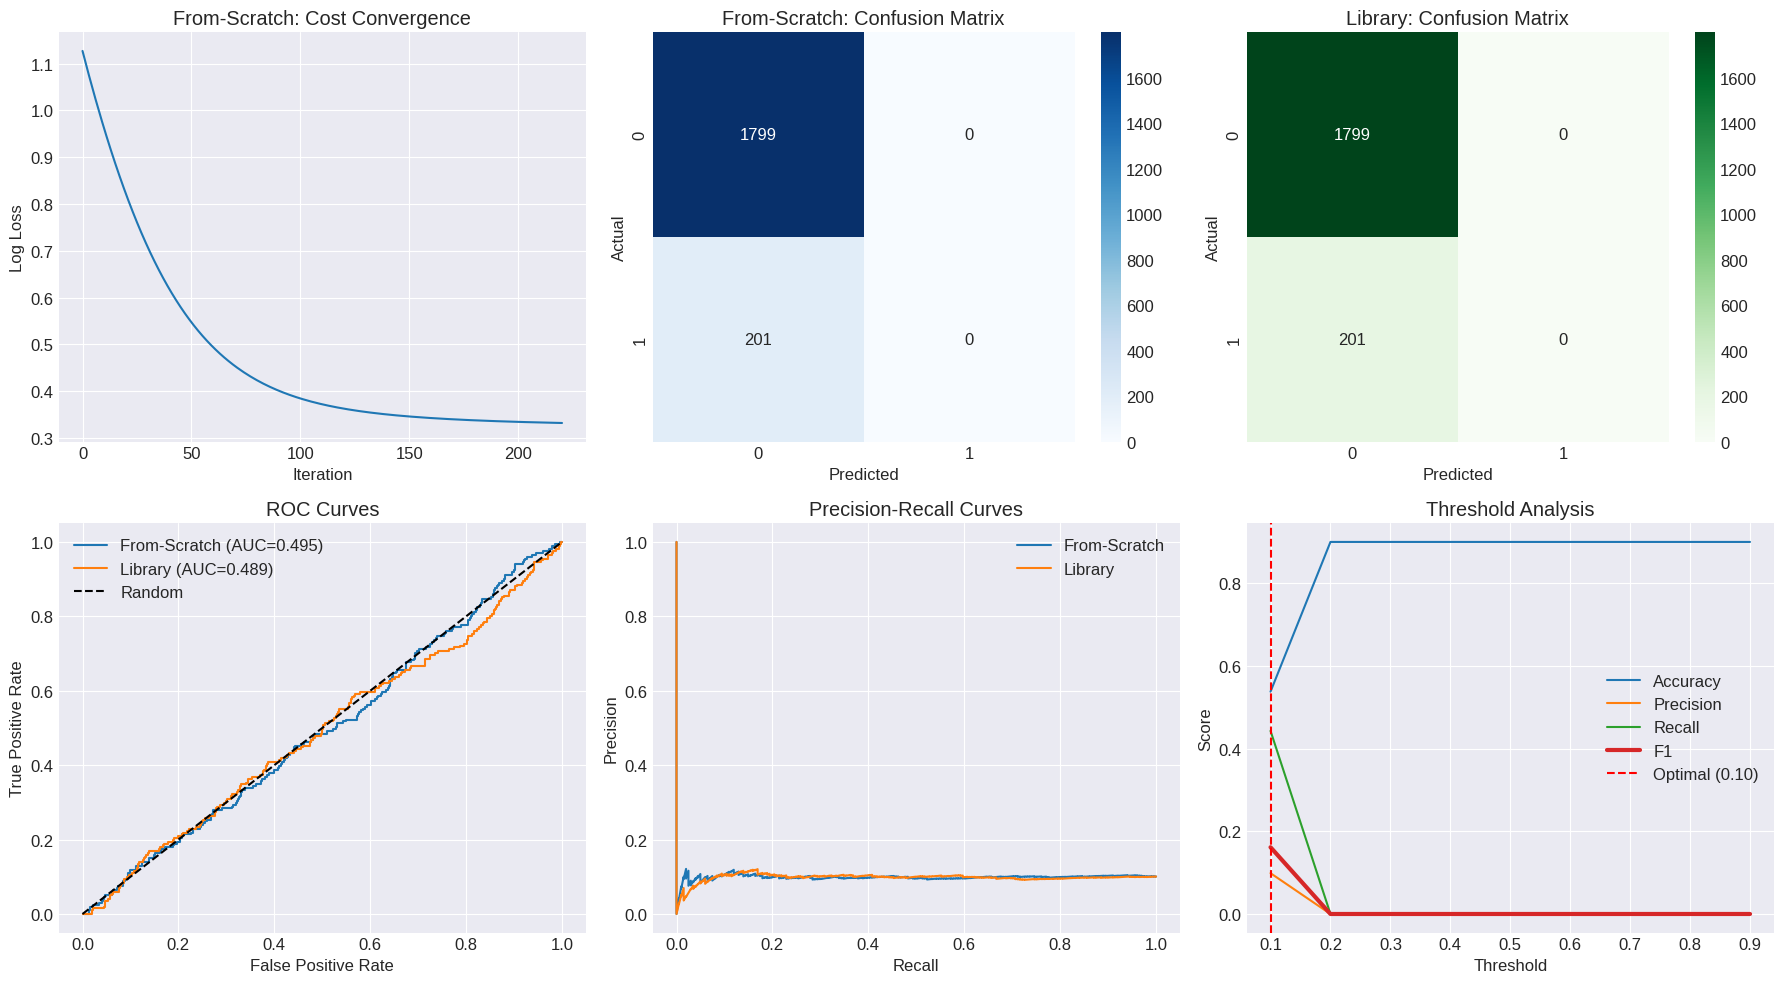

In [7]:

# LOGISTIC REGRESSION

print("\n" + "=" * 80)
print(" LOGISTIC REGRESSION")
print("=" * 80)

# 4.1 DATA PREPARATION FOR LOGISTIC REGRESSION
print("\n4.1 DATA PREPARATION FOR LOGISTIC REGRESSION")
print("-" * 40)

# Use the actual loan status if available, otherwise create binary target
if target_col in df.columns:
    y_class = df[target_col]
    # Convert to binary if needed
    if y_class.nunique() > 2:
        y_class = (y_class > y_class.median()).astype(int)
else:
    # Create binary target based on interest rate
    y_class = (df['Interest Rate'] > df['Interest Rate'].median()).astype(int)

# Select features for classification
class_features = [col for col in numerical_cols if col != target_col][:10]
X_class = df[class_features].fillna(df[class_features].median())

print(f"Classification Features: {class_features}")
print(f"Target distribution:\n{y_class.value_counts()}")

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Scale features
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# 4.2 Logistic Regression from Scratch
print("\n4.2 LOGISTIC REGRESSION FROM SCRATCH")
print("-" * 40)

class LogisticRegressionScratch:
    """Logistic Regression implementation from scratch"""

    def __init__(self, learning_rate=0.1, iterations=1000, tol=1e-4):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.tol = tol
        self.theta = None
        self.cost_history = []

    def sigmoid(self, z):
        """Sigmoid function"""
        return 1 / (1 + np.exp(-z))

    def cost_function(self, X, y, theta):
        """Log loss cost function"""
        m = len(y)
        h = self.sigmoid(X.dot(theta))
        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))
        return cost

    def fit(self, X, y):
        """Train the model using gradient descent"""
        # Add bias term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Initialize parameters
        m, n = X_b.shape
        self.theta = np.random.randn(n, 1)
        y = y.values.reshape(-1, 1) if hasattr(y, 'values') else y.reshape(-1, 1)

        # Gradient descent
        for i in range(self.iterations):
            # Calculate predictions
            z = X_b.dot(self.theta)
            h = self.sigmoid(z)

            # Calculate gradient
            gradient = (1/m) * X_b.T.dot(h - y)

            # Update parameters
            self.theta = self.theta - self.learning_rate * gradient

            # Calculate cost
            cost = self.cost_function(X_b, y, self.theta)
            self.cost_history.append(cost)

            # Check convergence
            if i > 0 and abs(self.cost_history[-1] - self.cost_history[-2]) < self.tol:
                print(f"Converged at iteration {i}")
                break

            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.6f}")

        return self

    def predict_proba(self, X):
        """Predict probabilities"""
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.theta)).flatten()

    def predict(self, X, threshold=0.5):
        """Make binary predictions"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def score(self, X, y):
        """Calculate accuracy"""
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

# Train from-scratch model
print("Training Logistic Regression from scratch...")
logreg_scratch = LogisticRegressionScratch(learning_rate=0.1, iterations=1000)
logreg_scratch.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_scratch_log = logreg_scratch.predict(X_test_class_scaled)
y_prob_scratch_log = logreg_scratch.predict_proba(X_test_class_scaled)

# Calculate metrics
accuracy_scratch_log = accuracy_score(y_test_class, y_pred_scratch_log)
precision_scratch_log = precision_score(y_test_class, y_pred_scratch_log)
recall_scratch_log = recall_score(y_test_class, y_pred_scratch_log)
f1_scratch_log = f1_score(y_test_class, y_pred_scratch_log)
auc_scratch_log = roc_auc_score(y_test_class, y_prob_scratch_log)

print(f"\nFrom-Scratch Model Performance:")
print(f"Accuracy: {accuracy_scratch_log:.4f}")
print(f"Precision: {precision_scratch_log:.4f}")
print(f"Recall: {recall_scratch_log:.4f}")
print(f"F1-Score: {f1_scratch_log:.4f}")
print(f"ROC-AUC: {auc_scratch_log:.4f}")

# 4.3 Logistic Regression using Library
print("\n4.3 LOGISTIC REGRESSION USING LIBRARY")
print("-" * 40)

# Train library model
logreg_library = LogisticRegression(max_iter=1000, random_state=42)
logreg_library.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_library_log = logreg_library.predict(X_test_class_scaled)
y_prob_library_log = logreg_library.predict_proba(X_test_class_scaled)[:, 1]

# Calculate metrics
accuracy_library_log = accuracy_score(y_test_class, y_pred_library_log)
precision_library_log = precision_score(y_test_class, y_pred_library_log)
recall_library_log = recall_score(y_test_class, y_pred_library_log)
f1_library_log = f1_score(y_test_class, y_pred_library_log)
auc_library_log = roc_auc_score(y_test_class, y_prob_library_log)

print("Library Model Performance:")
print(f"Accuracy: {accuracy_library_log:.4f}")
print(f"Precision: {precision_library_log:.4f}")
print(f"Recall: {recall_library_log:.4f}")
print(f"F1-Score: {f1_library_log:.4f}")
print(f"ROC-AUC: {auc_library_log:.4f}")

# 4.4 Threshold Analysis
print("\n4.4 THRESHOLD ANALYSIS AND PROBABILITY INTERPRETATION")
print("-" * 40)

# Analyze different thresholds
thresholds = np.arange(0.1, 1.0, 0.1)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_library_log >= threshold).astype(int)
    accuracy = accuracy_score(y_test_class, y_pred_thresh)
    precision = precision_score(y_test_class, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test_class, y_pred_thresh)
    f1 = f1_score(y_test_class, y_pred_thresh)
    results.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(results)
print("Performance at Different Thresholds:")
print(threshold_df)

# Find optimal threshold (max F1)
optimal_idx = threshold_df['F1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']
print(f"\nOptimal Threshold (max F1): {optimal_threshold:.2f}")

# 4.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Cost convergence
axes[0, 0].plot(logreg_scratch.cost_history)
axes[0, 0].set_title('From-Scratch: Cost Convergence')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Log Loss')
axes[0, 0].grid(True)

# Confusion Matrix (Scratch)
cm_scratch = confusion_matrix(y_test_class, y_pred_scratch_log)
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('From-Scratch: Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Confusion Matrix (Library)
cm_library = confusion_matrix(y_test_class, y_pred_library_log)
sns.heatmap(cm_library, annot=True, fmt='d', cmap='Greens', ax=axes[0, 2])
axes[0, 2].set_title('Library: Confusion Matrix')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# ROC Curve
fpr_scratch, tpr_scratch, _ = roc_curve(y_test_class, y_prob_scratch_log)
fpr_library, tpr_library, _ = roc_curve(y_test_class, y_prob_library_log)

axes[1, 0].plot(fpr_scratch, tpr_scratch, label=f'From-Scratch (AUC={auc_scratch_log:.3f})')
axes[1, 0].plot(fpr_library, tpr_library, label=f'Library (AUC={auc_library_log:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_title('ROC Curves')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision-Recall Curve
precision_scratch, recall_scratch, _ = precision_recall_curve(y_test_class, y_prob_scratch_log)
precision_library, recall_library, _ = precision_recall_curve(y_test_class, y_prob_library_log)

axes[1, 1].plot(recall_scratch, precision_scratch, label='From-Scratch')
axes[1, 1].plot(recall_library, precision_library, label='Library')
axes[1, 1].set_title('Precision-Recall Curves')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Threshold Analysis
axes[1, 2].plot(threshold_df['Threshold'], threshold_df['Accuracy'], label='Accuracy')
axes[1, 2].plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
axes[1, 2].plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
axes[1, 2].plot(threshold_df['Threshold'], threshold_df['F1'], label='F1', linewidth=3)
axes[1, 2].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
axes[1, 2].set_title('Threshold Analysis')
axes[1, 2].set_xlabel('Threshold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()


FEATURE REGULARIZATION TO PREVENT OVERFITTING

5.1 DATA PREPARATION FOR REGULARIZATION
----------------------------------------
Training set: (7999, 8)
Testing set: (2000, 8)

5.2 RIDGE REGRESSION (L2 Regularization)
----------------------------------------
Alpha =   0.001: R² = 0.9317
Alpha =   0.010: R² = 0.9317
Alpha =   0.100: R² = 0.9317
Alpha =   1.000: R² = 0.9317
Alpha =  10.000: R² = 0.9317
Alpha = 100.000: R² = 0.9314
Alpha = 1000.000: R² = 0.9188

Best Ridge Alpha: 0.001
Best R² Score: 0.9317

5.3 LASSO REGRESSION (L1 Regularization)
----------------------------------------
Alpha =   0.001: R² = 0.9317, Features selected: 8/8
Alpha =   0.010: R² = 0.9317, Features selected: 8/8
Alpha =   0.100: R² = 0.9317, Features selected: 8/8
Alpha =   1.000: R² = 0.9317, Features selected: 8/8
Alpha =  10.000: R² = 0.9317, Features selected: 6/8
Alpha = 100.000: R² = 0.9303, Features selected: 2/8
Alpha = 1000.000: R² = 0.8184, Features selected: 1/8

Best Lasso Alpha: 10
Best R² Score

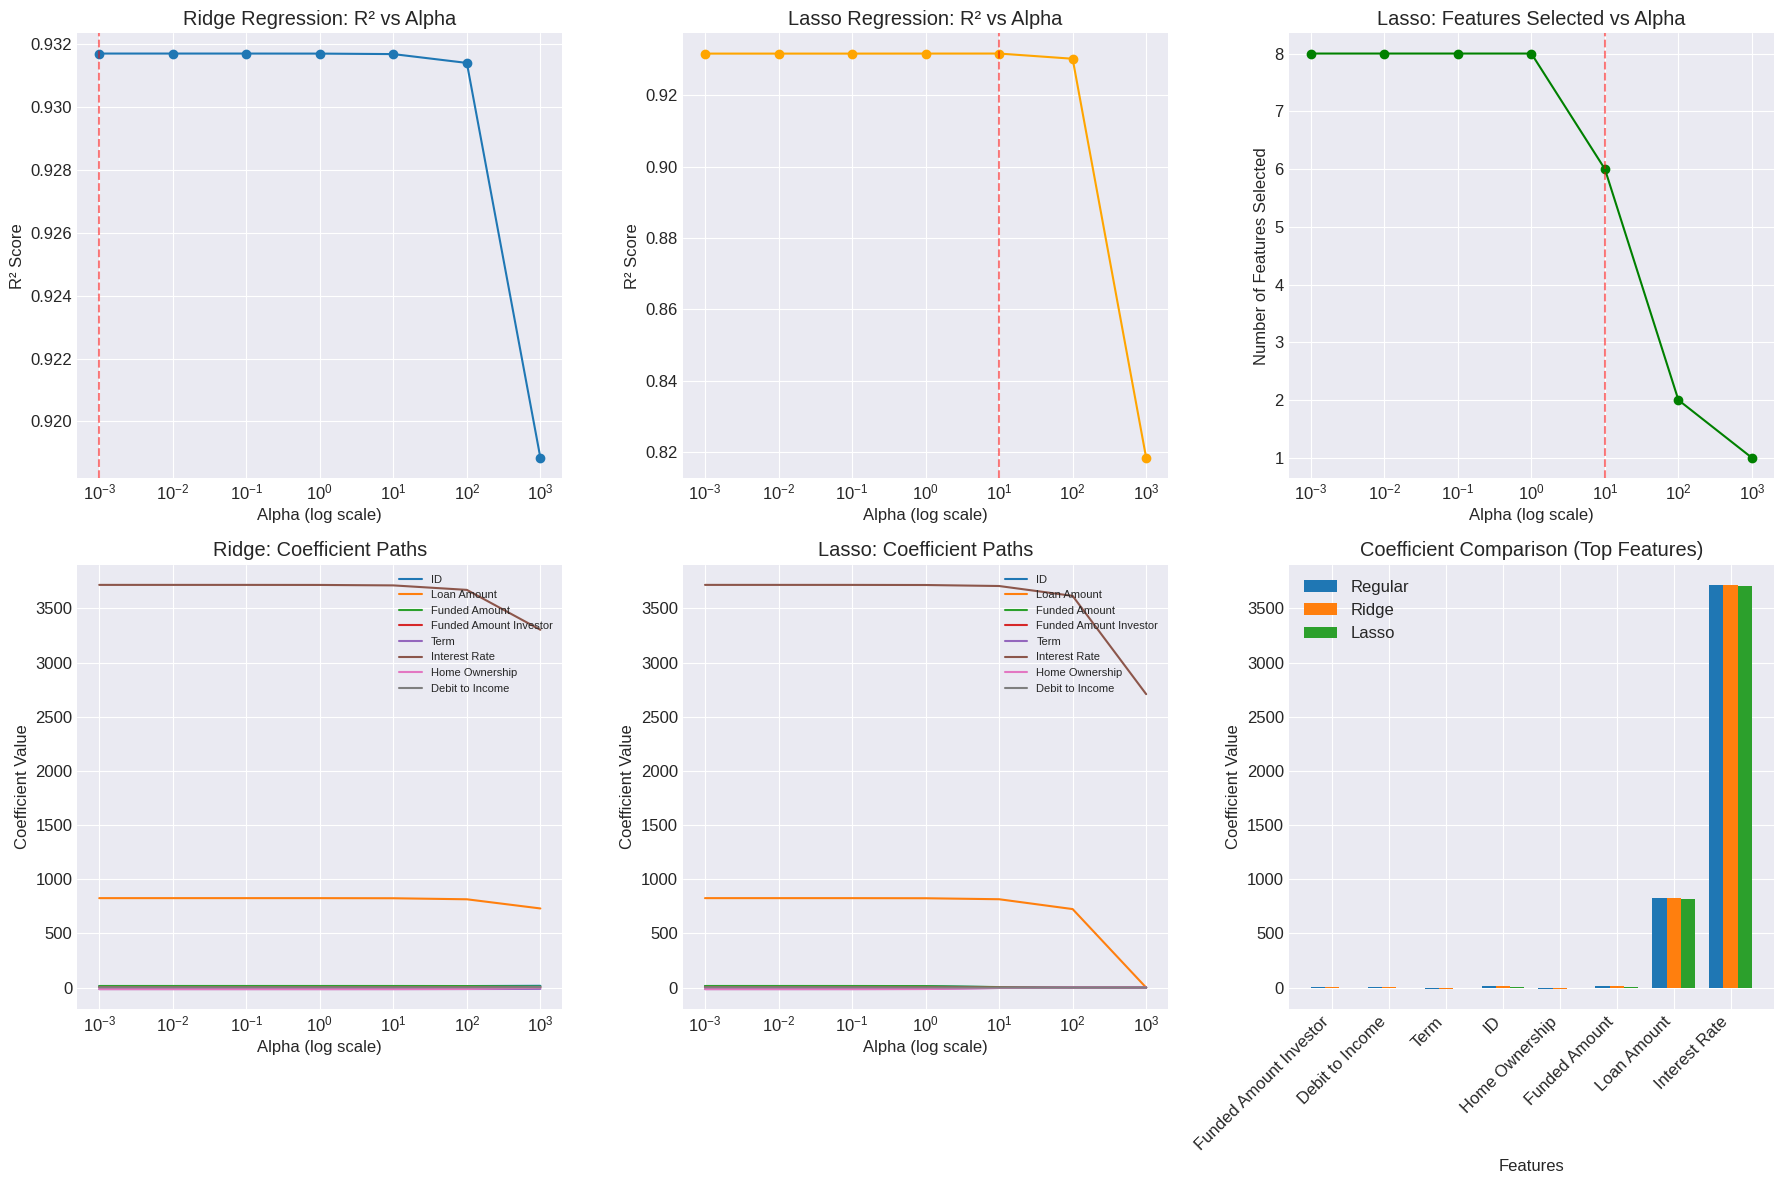


5.8 DEMONSTRATING OVERFITTING AND REGULARIZATION EFFECT
----------------------------------------
Polynomial Features (degree=4):
  Training R²: 0.0451
  Testing R²:  0.0330
  Gap: 0.0121 (indicates overfitting)

Ridge on Polynomial Features:
  Training R²: 0.0451
  Testing R²:  0.0332
  Gap: 0.0119 (reduced overfitting)


In [8]:

# FEATURE REGULARIZATION

print("\n" + "=" * 80)
print("FEATURE REGULARIZATION TO PREVENT OVERFITTING")
print("=" * 80)

# 5.1 Prepare Data for Regularization
print("\n5.1 DATA PREPARATION FOR REGULARIZATION")
print("-" * 40)

# Use the same data as linear regression
X_reg_regular = X_reg.copy()
y_reg_regular = y_reg.copy()

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_regular, y_reg_regular, test_size=0.2, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"Training set: {X_train_reg_scaled.shape}")
print(f"Testing set: {X_test_reg_scaled.shape}")

# 5.2 Ridge Regression
print("\n5.2 RIDGE REGRESSION (L2 Regularization)")
print("-" * 40)

# Test different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_scores = []
ridge_coeffs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_reg_scaled, y_train_reg)

    # Predict and score
    y_pred_ridge = ridge.predict(X_test_reg_scaled)
    score = r2_score(y_test_reg, y_pred_ridge)

    ridge_scores.append(score)
    ridge_coeffs.append(ridge.coef_)

    print(f"Alpha = {alpha:7.3f}: R² = {score:.4f}")

# Find best alpha
best_ridge_idx = np.argmax(ridge_scores)
best_ridge_alpha = alphas[best_ridge_idx]
best_ridge_score = ridge_scores[best_ridge_idx]

print(f"\nBest Ridge Alpha: {best_ridge_alpha}")
print(f"Best R² Score: {best_ridge_score:.4f}")

# 5.3 Lasso Regression
print("\n5.3 LASSO REGRESSION (L1 Regularization)")
print("-" * 40)

lasso_scores = []
lasso_coeffs = []
n_selected_features = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso.fit(X_train_reg_scaled, y_train_reg)

    # Predict and score
    y_pred_lasso = lasso.predict(X_test_reg_scaled)
    score = r2_score(y_test_reg, y_pred_lasso)

    lasso_scores.append(score)
    lasso_coeffs.append(lasso.coef_)
    n_selected_features.append(np.sum(lasso.coef_ != 0))

    print(f"Alpha = {alpha:7.3f}: R² = {score:.4f}, Features selected: {n_selected_features[-1]}/{len(lasso.coef_)}")

# Find best alpha
best_lasso_idx = np.argmax(lasso_scores)
best_lasso_alpha = alphas[best_lasso_idx]
best_lasso_score = lasso_scores[best_lasso_idx]

print(f"\nBest Lasso Alpha: {best_lasso_alpha}")
print(f"Best R² Score: {best_lasso_score:.4f}")
print(f"Features selected at best alpha: {n_selected_features[best_lasso_idx]}/{len(lasso_coeffs[best_lasso_idx])}")

# 5.4 ElasticNet
print("\n5.4 ELASTIC NET REGULARIZATION")
print("-" * 40)

elastic_scores = []
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

for l1_ratio in l1_ratios:
    elastic = ElasticNet(alpha=0.1, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
    elastic.fit(X_train_reg_scaled, y_train_reg)

    y_pred_elastic = elastic.predict(X_test_reg_scaled)
    score = r2_score(y_test_reg, y_pred_elastic)
    elastic_scores.append(score)

    print(f"L1 Ratio = {l1_ratio}: R² = {score:.4f}")

# 5.5 Compare with Regular Linear Regression
print("\n5.5 COMPARISON WITH REGULAR LINEAR REGRESSION")
print("-" * 40)

# Train regular linear regression
lr_regular = LinearRegression()
lr_regular.fit(X_train_reg_scaled, y_train_reg)
y_pred_regular = lr_regular.predict(X_test_reg_scaled)
regular_score = r2_score(y_test_reg, y_pred_regular)

print(f"Regular Linear Regression R²: {regular_score:.4f}")
print(f"Ridge Regression (best) R²: {best_ridge_score:.4f}")
print(f"Lasso Regression (best) R²: {best_lasso_score:.4f}")

# 5.6 Coefficient Analysis
print("\n5.6 COEFFICIENT ANALYSIS")
print("-" * 40)

# Get coefficients at best parameters
best_ridge = Ridge(alpha=best_ridge_alpha, random_state=42)
best_ridge.fit(X_train_reg_scaled, y_train_reg)

best_lasso = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=10000)
best_lasso.fit(X_train_reg_scaled, y_train_reg)

# Create coefficient comparison dataframe
coeff_comparison = pd.DataFrame({
    'Feature': reg_features,
    'Regular': lr_regular.coef_,
    'Ridge': best_ridge.coef_,
    'Lasso': best_lasso.coef_
})

print("Coefficient Comparison (Top 10 features by absolute value in Regular):")
top_features_idx = np.argsort(np.abs(lr_regular.coef_))[-10:]
print(coeff_comparison.iloc[top_features_idx].sort_values('Regular', key=abs, ascending=False))

# 5.7 Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# R² vs Alpha (Ridge)
axes[0, 0].semilogx(alphas, ridge_scores, marker='o')
axes[0, 0].axvline(x=best_ridge_alpha, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Ridge Regression: R² vs Alpha')
axes[0, 0].set_xlabel('Alpha (log scale)')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].grid(True)

# R² vs Alpha (Lasso)
axes[0, 1].semilogx(alphas, lasso_scores, marker='o', color='orange')
axes[0, 1].axvline(x=best_lasso_alpha, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Lasso Regression: R² vs Alpha')
axes[0, 1].set_xlabel('Alpha (log scale)')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].grid(True)

# Features selected vs Alpha (Lasso)
axes[0, 2].semilogx(alphas, n_selected_features, marker='o', color='green')
axes[0, 2].axvline(x=best_lasso_alpha, color='r', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Lasso: Features Selected vs Alpha')
axes[0, 2].set_xlabel('Alpha (log scale)')
axes[0, 2].set_ylabel('Number of Features Selected')
axes[0, 2].grid(True)

# Coefficient paths (Ridge)
coeff_array_ridge = np.array(ridge_coeffs).T
for i, coeff_path in enumerate(coeff_array_ridge):
    if i < 8:  # Plot first 8 features
        axes[1, 0].semilogx(alphas, coeff_path, label=reg_features[i] if i < len(reg_features) else f'Feature {i}')
axes[1, 0].set_title('Ridge: Coefficient Paths')
axes[1, 0].set_xlabel('Alpha (log scale)')
axes[1, 0].set_ylabel('Coefficient Value')
axes[1, 0].legend(loc='upper right', fontsize=8)
axes[1, 0].grid(True)

# Coefficient paths (Lasso)
coeff_array_lasso = np.array(lasso_coeffs).T
for i, coeff_path in enumerate(coeff_array_lasso):
    if i < 8:  # Plot first 8 features
        axes[1, 1].semilogx(alphas, coeff_path, label=reg_features[i] if i < len(reg_features) else f'Feature {i}')
axes[1, 1].set_title('Lasso: Coefficient Paths')
axes[1, 1].set_xlabel('Alpha (log scale)')
axes[1, 1].set_ylabel('Coefficient Value')
axes[1, 1].legend(loc='upper right', fontsize=8)
axes[1, 1].grid(True)

# Coefficient comparison bar chart
top_n = 8
x_pos = np.arange(top_n)
width = 0.25

top_idx = np.argsort(np.abs(lr_regular.coef_))[-top_n:]
top_features = [reg_features[i] for i in top_idx]

axes[1, 2].bar(x_pos - width, lr_regular.coef_[top_idx], width, label='Regular')
axes[1, 2].bar(x_pos, best_ridge.coef_[top_idx], width, label='Ridge')
axes[1, 2].bar(x_pos + width, best_lasso.coef_[top_idx], width, label='Lasso')
axes[1, 2].set_title('Coefficient Comparison (Top Features)')
axes[1, 2].set_xlabel('Features')
axes[1, 2].set_ylabel('Coefficient Value')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(top_features, rotation=45, ha='right')
axes[1, 2].legend()
axes[1, 2].grid(True, axis='y')

plt.tight_layout()
plt.show()

# 5.8 Overfitting Demonstration
print("\n5.8 DEMONSTRATING OVERFITTING AND REGULARIZATION EFFECT")
print("-" * 40)

# Create polynomial features to demonstrate overfitting
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X_train_reg_scaled[:, :3])  # Use first 3 features only

# Train on polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_train_reg)

# Create test polynomial features
X_test_poly = poly.transform(X_test_reg_scaled[:, :3])

# Predict
y_train_pred_poly = lr_poly.predict(X_poly)
y_test_pred_poly = lr_poly.predict(X_test_poly)

# Calculate scores
train_score_poly = r2_score(y_train_reg, y_train_pred_poly)
test_score_poly = r2_score(y_test_reg, y_test_pred_poly)

print(f"Polynomial Features (degree=4):")
print(f"  Training R²: {train_score_poly:.4f}")
print(f"  Testing R²:  {test_score_poly:.4f}")
print(f"  Gap: {train_score_poly - test_score_poly:.4f} (indicates overfitting)")

# Apply Ridge to polynomial features
ridge_poly = Ridge(alpha=10)
ridge_poly.fit(X_poly, y_train_reg)

y_train_pred_ridge_poly = ridge_poly.predict(X_poly)
y_test_pred_ridge_poly = ridge_poly.predict(X_test_poly)

train_score_ridge_poly = r2_score(y_train_reg, y_train_pred_ridge_poly)
test_score_ridge_poly = r2_score(y_test_reg, y_test_pred_ridge_poly)

print(f"\nRidge on Polynomial Features:")
print(f"  Training R²: {train_score_ridge_poly:.4f}")
print(f"  Testing R²:  {test_score_ridge_poly:.4f}")
print(f"  Gap: {train_score_ridge_poly - test_score_ridge_poly:.4f} (reduced overfitting)")


SUPPORT VECTOR MACHINE (SVM)

6.1 DATA PREPARATION FOR SVM
----------------------------------------
Training set: (7999, 10)
Testing set: (2000, 10)
Class distribution (train): [7195  804]
Class distribution (test): [1799  201]

6.2 SVM WITH DIFFERENT KERNELS
----------------------------------------

Training SVM with linear kernel...
  Accuracy: 0.8995
  F1-Score: 0.0000
  AUC: 0.5325
  Support Vectors: 1861

Training SVM with poly kernel...
  Accuracy: 0.8980
  F1-Score: 0.0000
  AUC: 0.5333
  Support Vectors: 1787

Training SVM with rbf kernel...
  Accuracy: 0.8995
  F1-Score: 0.0000
  AUC: 0.4871
  Support Vectors: 2786

Training SVM with sigmoid kernel...
  Accuracy: 0.8500
  F1-Score: 0.0909
  AUC: 0.5028
  Support Vectors: 1534

SVM Performance Summary:
    Kernel  Accuracy  Precision    Recall        F1       AUC  Support_Vectors
0   linear    0.8995   0.000000  0.000000  0.000000  0.532499             1861
1     poly    0.8980   0.000000  0.000000  0.000000  0.533303         

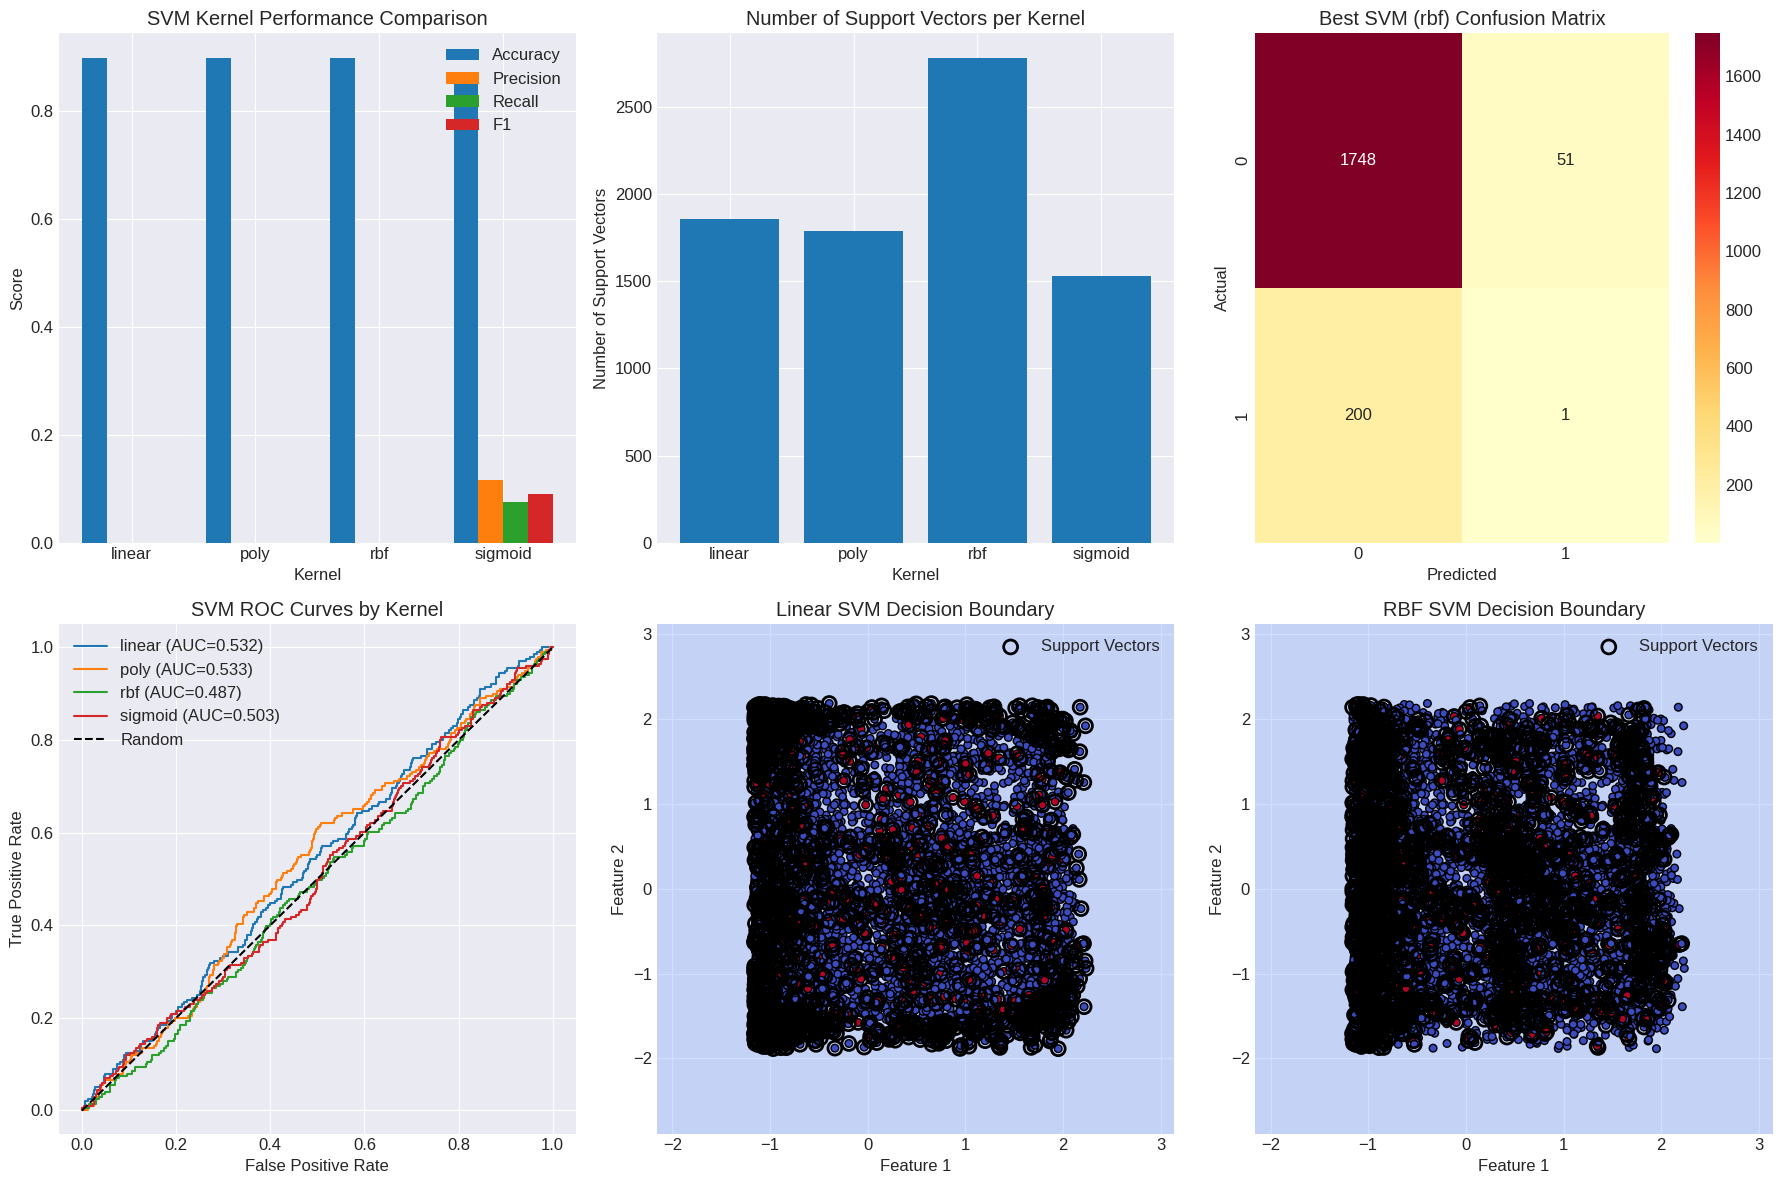


6.6 MARGIN ANALYSIS FOR LINEAR SVM
----------------------------------------
Margin width: 71193.8078
Support vector distances to hyperplane:
  Min: 35595.6413
  Max: 35599.1206
  Mean: 35596.7995


In [10]:

# SUPPORT VECTOR MACHINE (SVM)

print("\n" + "=" * 80)
print("SUPPORT VECTOR MACHINE (SVM)")
print("=" * 80)

# 6.1 Prepare Data for SVM
print("\n6.1 DATA PREPARATION FOR SVM")
print("-" * 40)

# Use classification data
X_svm = X_class.copy()
y_svm = y_class.copy()

# Split data
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)

# Scale features (important for SVM)
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

print(f"Training set: {X_train_svm_scaled.shape}")
print(f"Testing set: {X_test_svm_scaled.shape}")
print(f"Class distribution (train): {np.bincount(y_train_svm)}")
print(f"Class distribution (test): {np.bincount(y_test_svm)}")

# 6.2 SVM with Different Kernels
print("\n6.2 SVM WITH DIFFERENT KERNELS")
print("-" * 40)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_results = []

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")

    # Create SVM classifier
    if kernel == 'linear':
        svm = SVC(kernel=kernel, C=1.0, random_state=42, probability=True)
    elif kernel == 'poly':
        svm = SVC(kernel=kernel, C=1.0, degree=3, random_state=42, probability=True)
    else:
        svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42, probability=True)

    # Train
    svm.fit(X_train_svm_scaled, y_train_svm)

    # Predict
    y_pred_svm = svm.predict(X_test_svm_scaled)
    y_prob_svm = svm.predict_proba(X_test_svm_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test_svm, y_pred_svm)
    precision = precision_score(y_test_svm, y_pred_svm)
    recall = recall_score(y_test_svm, y_pred_svm)
    f1 = f1_score(y_test_svm, y_pred_svm)
    auc_score = roc_auc_score(y_test_svm, y_prob_svm)

    # Store results
    svm_results.append({
        'Kernel': kernel,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc_score,
        'Support_Vectors': len(svm.support_)
    })

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC: {auc_score:.4f}")
    print(f"  Support Vectors: {len(svm.support_)}")

svm_results_df = pd.DataFrame(svm_results)
print("\nSVM Performance Summary:")
print(svm_results_df)

# 6.3 Hyperparameter Tuning for SVM
print("\n6.3 SVM HYPERPARAMETER TUNING")
print("-" * 40)

# Tune RBF kernel SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Use smaller sample for faster grid search
sample_size = min(1000, len(X_train_svm_scaled))
X_sample = X_train_svm_scaled[:sample_size]
y_sample = y_train_svm[:sample_size]

print("Performing Grid Search for RBF SVM (using sample)...")
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_sample, y_sample)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train best model on full data
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_svm_scaled, y_train_svm)

# Evaluate best model
y_pred_best_svm = best_svm.predict(X_test_svm_scaled)
y_prob_best_svm = best_svm.predict_proba(X_test_svm_scaled)[:, 1]

best_accuracy = accuracy_score(y_test_svm, y_pred_best_svm)
best_f1 = f1_score(y_test_svm, y_pred_best_svm)
best_auc = roc_auc_score(y_test_svm, y_prob_best_svm)

print(f"\nBest SVM Performance:")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  F1-Score: {best_f1:.4f}")
print(f"  AUC: {best_auc:.4f}")

# 6.4 Support Vectors Analysis
print("\n6.4 SUPPORT VECTORS ANALYSIS")
print("-" * 40)

# Get support vectors for linear kernel
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_svm_scaled[:, :2], y_train_svm)  # Use 2D for visualization

print(f"Linear SVM Support Vectors: {len(svm_linear.support_vectors_)}")
print(f"Number of support vectors per class: {np.bincount(y_train_svm.iloc[svm_linear.support_])}")

# 6.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Kernel Performance Comparison
x_pos = np.arange(len(kernels))
width = 0.2

axes[0, 0].bar(x_pos - 1.5*width, svm_results_df['Accuracy'], width, label='Accuracy')
axes[0, 0].bar(x_pos - 0.5*width, svm_results_df['Precision'], width, label='Precision')
axes[0, 0].bar(x_pos + 0.5*width, svm_results_df['Recall'], width, label='Recall')
axes[0, 0].bar(x_pos + 1.5*width, svm_results_df['F1'], width, label='F1')
axes[0, 0].set_title('SVM Kernel Performance Comparison')
axes[0, 0].set_xlabel('Kernel')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(kernels)
axes[0, 0].legend()
axes[0, 0].grid(True, axis='y')

# Support Vectors per Kernel
axes[0, 1].bar(kernels, svm_results_df['Support_Vectors'])
axes[0, 1].set_title('Number of Support Vectors per Kernel')
axes[0, 1].set_xlabel('Kernel')
axes[0, 1].set_ylabel('Number of Support Vectors')
axes[0, 1].grid(True, axis='y')

# Confusion Matrix for Best SVM
cm_best_svm = confusion_matrix(y_test_svm, y_pred_best_svm)
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 2])
axes[0, 2].set_title(f'Best SVM ({grid_search.best_params_["kernel"]}) Confusion Matrix')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# ROC Curves for Different Kernels
for idx, kernel in enumerate(kernels):
    svm_kernel = SVC(kernel=kernel, C=1.0, probability=True, random_state=42)
    svm_kernel.fit(X_train_svm_scaled, y_train_svm)
    y_prob_kernel = svm_kernel.predict_proba(X_test_svm_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_svm, y_prob_kernel)
    auc_kernel = roc_auc_score(y_test_svm, y_prob_kernel)
    axes[1, 0].plot(fpr, tpr, label=f'{kernel} (AUC={auc_kernel:.3f})')

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_title('SVM ROC Curves by Kernel')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Decision Boundary Visualization (2D)
def plot_decision_boundary(clf, X, y, ax, title):
    """Plot decision boundary for 2D data"""
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for each point in mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and margins
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap='coolwarm')

    # Plot support vectors
    if hasattr(clf, 'support_vectors_'):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                  s=100, facecolors='none', edgecolors='k', linewidths=2,
                  label='Support Vectors')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend()

# Train SVMs on 2D data for visualization
X_2d = X_train_svm_scaled[:, :2]

# Linear SVM
svm_linear_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear_2d.fit(X_2d, y_train_svm)
plot_decision_boundary(svm_linear_2d, X_2d, y_train_svm, axes[1, 1], 'Linear SVM Decision Boundary')

# RBF SVM
svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf_2d.fit(X_2d, y_train_svm)
plot_decision_boundary(svm_rbf_2d, X_2d, y_train_svm, axes[1, 2], 'RBF SVM Decision Boundary')

plt.tight_layout()
plt.show()

# 6.6 Margin Analysis
print("\n6.6 MARGIN ANALYSIS FOR LINEAR SVM")
print("-" * 40)

# Calculate margins for linear SVM
if hasattr(svm_linear, 'coef_'):
    w = svm_linear.coef_[0]
    margin = 2 / np.sqrt(np.sum(w ** 2))
    print(f"Margin width: {margin:.4f}")

    # Calculate distance of support vectors to hyperplane
    if len(svm_linear.support_vectors_) > 0:
        distances = np.abs(np.dot(svm_linear.support_vectors_, w) + svm_linear.intercept_[0]) / np.linalg.norm(w)
        print(f"Support vector distances to hyperplane:")
        print(f"  Min: {distances.min():.4f}")
        print(f"  Max: {distances.max():.4f}")
        print(f"  Mean: {distances.mean():.4f}")

LOADING DATA
X shape: (9999, 10)
y shape: (9999,)
Classes: [8994 1005]

Training set: (7999, 10)
Testing set: (2000, 10)

 CLASSIFIER MODELS

7.2 TRAINING AND EVALUATING CLASSIFIERS
----------------------------------------

Training Naive Bayes...
  Training Accuracy: 0.8770
  Testing Accuracy: 0.8725
  Precision: 0.0345
  Recall: 0.0100
  F1-Score: 0.0154

Training K-Nearest Neighbors...
  Training Accuracy: 0.8999
  Testing Accuracy: 0.8935
  Precision: 0.1250
  Recall: 0.0100
  F1-Score: 0.0184

Training Decision Tree...
  Training Accuracy: 1.0000
  Testing Accuracy: 0.8090
  Precision: 0.1082
  Recall: 0.1244
  F1-Score: 0.1157
  ⚠️ Potential overfitting: 0.1910

Training Random Forest...
  Training Accuracy: 1.0000
  Testing Accuracy: 0.8995
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  ⚠️ Potential overfitting: 0.1005

7.3 RESULTS COMPARISON
----------------------------------------

Performance Summary:
         Classifier  Train_Accuracy  Test_Accuracy  Precision   

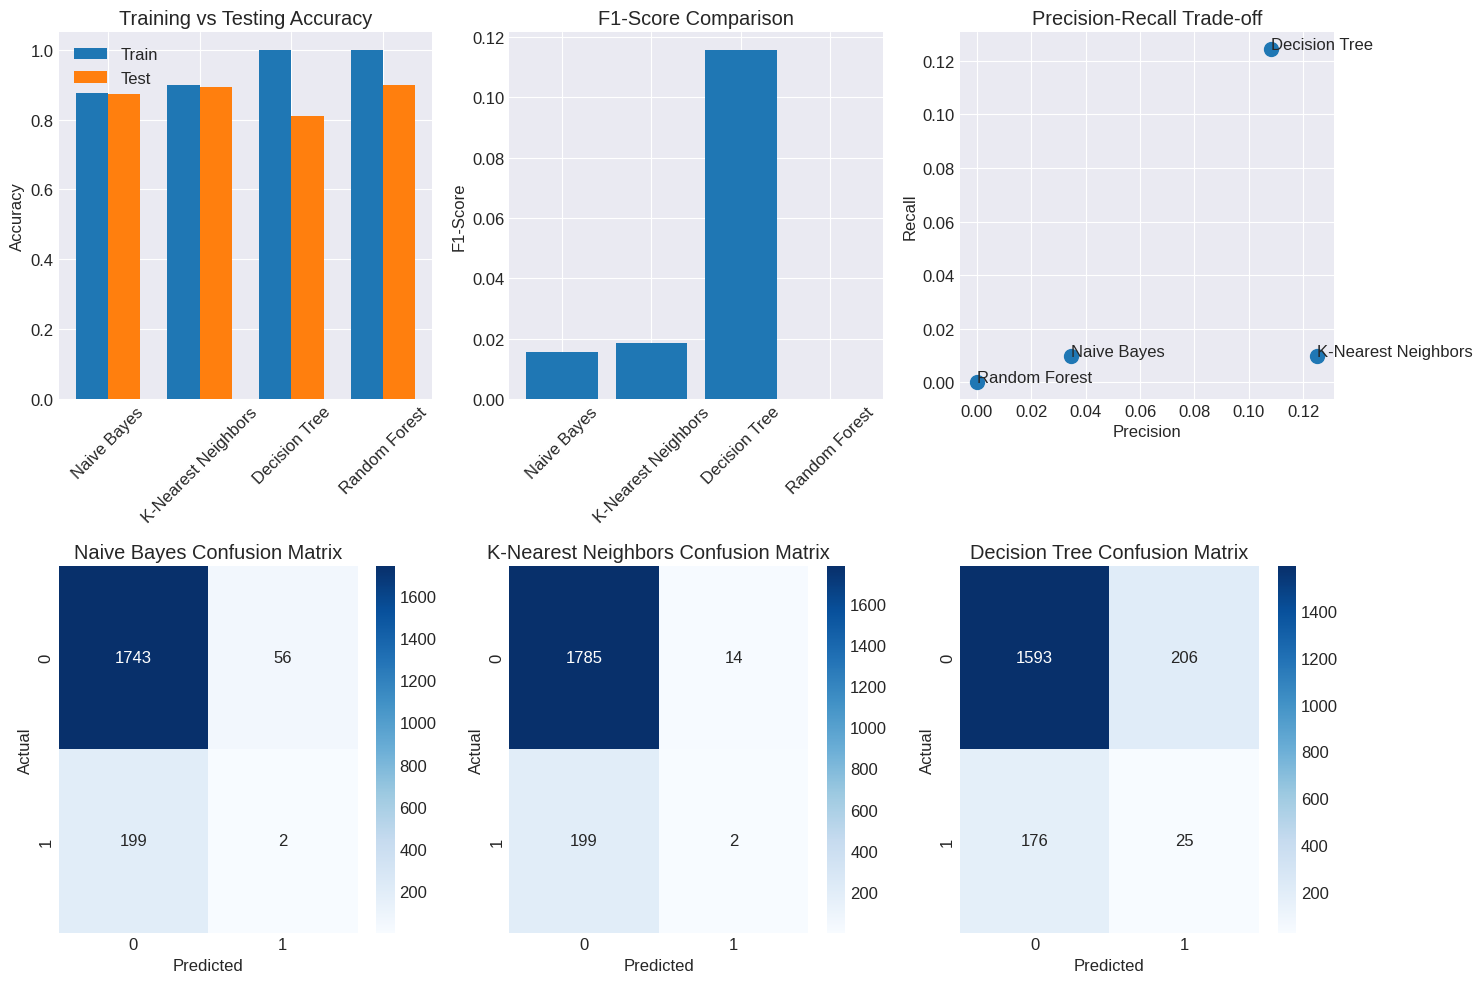

In [11]:

#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, mean_squared_error, r2_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.mixture import GaussianMixture

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")
# LOAD AND PREPARE DATA

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load data
df = pd.read_csv('ML_dataset.csv')

# Prepare features and target
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Select target
if 'Loan Status' in df.columns:
    target_col = 'Loan Status'
else:
    target_col = df.columns[-1]

# Create binary target if needed
if df[target_col].nunique() > 2:
    # Create binary classification
    y = (df[numerical_cols[0]] > df[numerical_cols[0]].median()).astype(int)
else:
    y = df[target_col]

# Select features (first 10 numerical columns)
X = df[numerical_cols[:10]].fillna(df[numerical_cols[:10]].median())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {np.bincount(y)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")


# CLASSIFIER MODELS

print("\n" + "=" * 60)
print(" CLASSIFIER MODELS")
print("=" * 60)

# 7.1 Initialize classifiers
classifiers = {
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 7.2 Train and evaluate
print("\n7.2 TRAINING AND EVALUATING CLASSIFIERS")
print("-" * 40)

results = []
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    # Train
    clf.fit(X_train_scaled, y_train)

    # Predict
    y_pred = clf.predict(X_test_scaled)
    y_pred_train = clf.predict(X_train_scaled)

    # Calculate metrics
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store results
    results.append({
        'Classifier': name,
        'Train_Accuracy': acc_train,
        'Test_Accuracy': acc_test,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

    print(f"  Training Accuracy: {acc_train:.4f}")
    print(f"  Testing Accuracy: {acc_test:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    # Check for overfitting
    overfit = acc_train - acc_test
    if overfit > 0.1:
        print(f"  ⚠️ Potential overfitting: {overfit:.4f}")

# 7.3 Results comparison
print("\n7.3 RESULTS COMPARISON")
print("-" * 40)

results_df = pd.DataFrame(results)
print("\nPerformance Summary:")
print(results_df.to_string(index=False))

# 7.4 Strengths and Limitations Analysis
print("\n7.4 STRENGTHS AND LIMITATIONS")
print("-" * 40)

analysis = {
    'Naive Bayes': {
        'Strengths': 'Fast training, works well with high dimensions, needs little data',
        'Limitations': 'Assumes feature independence (often incorrect)'
    },
    'K-Nearest Neighbors': {
        'Strengths': 'Simple, no training phase, works with non-linear data',
        'Limitations': 'Slow prediction, sensitive to irrelevant features'
    },
    'Decision Tree': {
        'Strengths': 'Easy to interpret, handles non-linear relationships',
        'Limitations': 'Prone to overfitting, unstable with small changes'
    },
    'Random Forest': {
        'Strengths': 'Reduces overfitting, handles non-linear data well',
        'Limitations': 'Less interpretable, slower training'
    }
}

for name, info in analysis.items():
    print(f"\n{name}:")
    print(f"  Strengths: {info['Strengths']}")
    print(f"  Limitations: {info['Limitations']}")

# 7.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Accuracy comparison
x_pos = np.arange(len(classifiers))
width = 0.35
axes[0, 0].bar(x_pos - width/2, results_df['Train_Accuracy'], width, label='Train')
axes[0, 0].bar(x_pos + width/2, results_df['Test_Accuracy'], width, label='Test')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(results_df['Classifier'], rotation=45)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Training vs Testing Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, axis='y')

# F1-Score comparison
axes[0, 1].bar(results_df['Classifier'], results_df['F1_Score'])
axes[0, 1].set_xticklabels(results_df['Classifier'], rotation=45)
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('F1-Score Comparison')
axes[0, 1].grid(True, axis='y')

# Precision-Recall trade-off
axes[0, 2].scatter(results_df['Precision'], results_df['Recall'], s=100)
for i, row in results_df.iterrows():
    axes[0, 2].annotate(row['Classifier'], (row['Precision'], row['Recall']))
axes[0, 2].set_xlabel('Precision')
axes[0, 2].set_ylabel('Recall')
axes[0, 2].set_title('Precision-Recall Trade-off')
axes[0, 2].grid(True)

# Confusion Matrices (first 3 classifiers)
for idx, (name, clf) in enumerate(list(classifiers.items())[:3]):
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    row = 1
    col = idx
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col])
    axes[row, col].set_title(f'{name} Confusion Matrix')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

plt.tight_layout()
plt.show()



 NEURAL NETWORKS

8.1 SINGLE-LAYER PERCEPTRON (FROM SCRATCH)
----------------------------------------
Training Single-Layer Perceptron from scratch...
Epoch 0: Accuracy = 0.7322
Epoch 20: Accuracy = 0.7710
Epoch 40: Accuracy = 0.7323
Epoch 60: Accuracy = 0.7387
Epoch 80: Accuracy = 0.6706
Test Accuracy (from scratch): 0.7195

8.2 MULTI-LAYER PERCEPTRON (MLP)
----------------------------------------
Simple MLP (10 neurons): Accuracy = 0.8995
Deep MLP (64-32-16): Accuracy = 0.8225

8.3 CONVOLUTIONAL NEURAL NETWORK (CNN) - FOR TABULAR DATA
----------------------------------------
Note: CNNs are designed for image data.
For tabular data, we use a 1D CNN approach.
Reshaped to: (7999, 10, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)


Training 1D CNN...
Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8620 - loss: 0.4231 - val_accuracy: 0.8925 - val_loss: 0.3520
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9015 - loss: 0.3408 - val_accuracy: 0.8925 - val_loss: 0.3423
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8959 - loss: 0.3472 - val_accuracy: 0.8925 - val_loss: 0.3494
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9018 - loss: 0.3301 - val_accuracy: 0.8925 - val_loss: 0.3408
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9010 - loss: 0.3297 - val_accuracy: 0.8925 - val_loss: 0.3396
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9000 - loss: 0.3329 - val_accuracy: 0.8925 - val_loss: 0.3390
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9041 - loss: 0.3247 - val_accuracy: 0.8925 - val_loss: 0.3394
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9020 - loss: 0.32

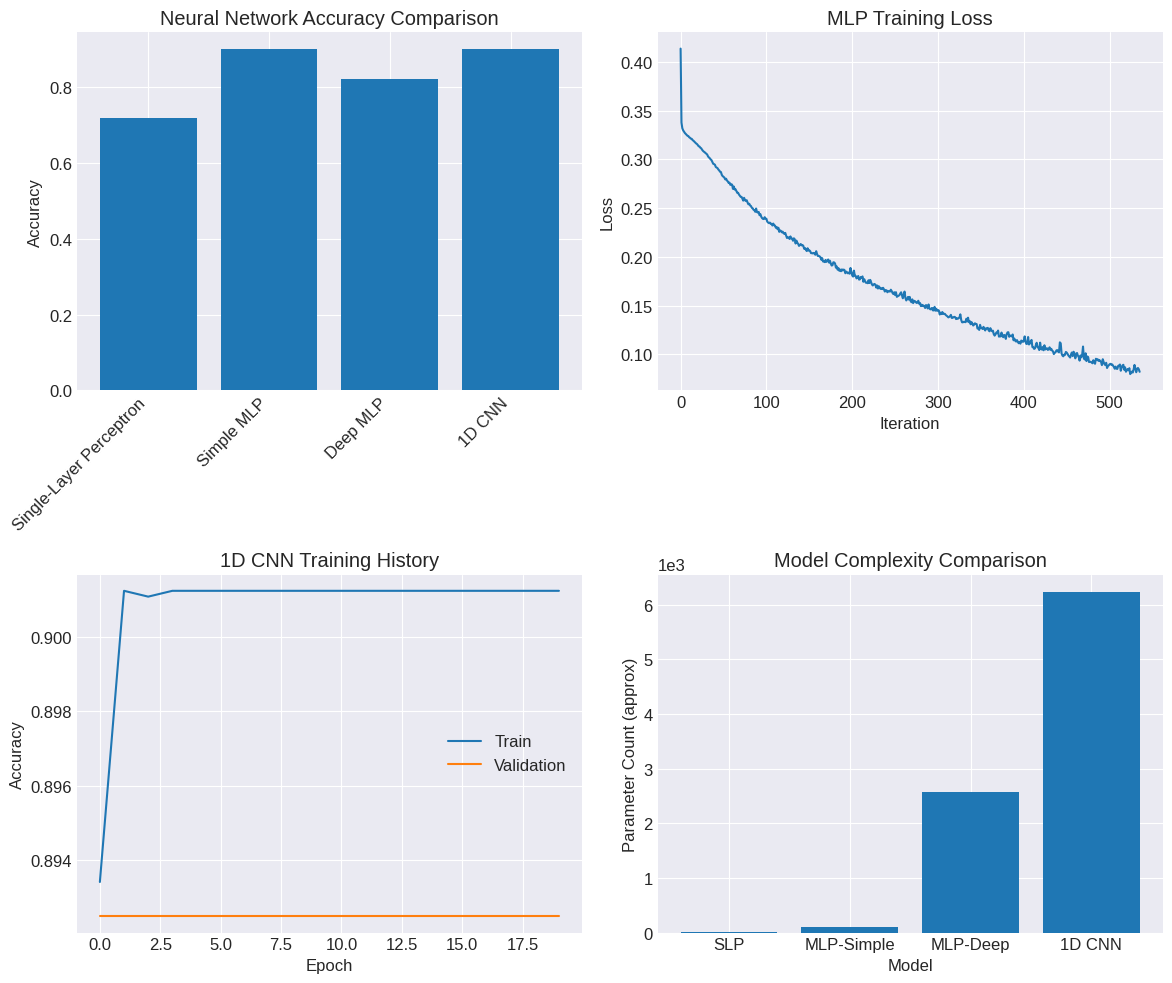

In [12]:

#  NEURAL NETWORKS
print("\n" + "=" * 60)
print(" NEURAL NETWORKS")
print("=" * 60)

# 8.1 Single-Layer Perceptron (from scratch)
print("\n8.1 SINGLE-LAYER PERCEPTRON (FROM SCRATCH)")
print("-" * 40)

class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        # Step activation
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            for idx in range(n_samples):
                # Forward pass
                linear = np.dot(X[idx], self.weights) + self.bias
                y_pred = self.activation(linear)

                # Update weights
                update = self.lr * (y.iloc[idx] - y_pred)
                self.weights += update * X[idx]
                self.bias += update

            if epoch % 20 == 0:
                accuracy = self.score(X, y)
                print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

        return self

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

# Train from-scratch perceptron
print("Training Single-Layer Perceptron from scratch...")
slp = SingleLayerPerceptron(learning_rate=0.1, epochs=100)
slp.fit(X_train_scaled, y_train)
slp_acc = slp.score(X_test_scaled, y_test)
print(f"Test Accuracy (from scratch): {slp_acc:.4f}")

# 8.2 Multi-Layer Perceptron (MLP) using scikit-learn
print("\n8.2 MULTI-LAYER PERCEPTRON (MLP)")
print("-" * 40)

# Simple MLP
mlp_simple = MLPClassifier(hidden_layer_sizes=(10,),
                          max_iter=1000,
                          random_state=42)
mlp_simple.fit(X_train_scaled, y_train)
mlp_simple_acc = mlp_simple.score(X_test_scaled, y_test)
print(f"Simple MLP (10 neurons): Accuracy = {mlp_simple_acc:.4f}")

# Deeper MLP
mlp_deep = MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                        max_iter=1000,
                        random_state=42,
                        learning_rate_init=0.001)
mlp_deep.fit(X_train_scaled, y_train)
mlp_deep_acc = mlp_deep.score(X_test_scaled, y_test)
print(f"Deep MLP (64-32-16): Accuracy = {mlp_deep_acc:.4f}")

# 8.3 CNN for comparison (using Keras) - FIXED VERSION
print("\n8.3 CONVOLUTIONAL NEURAL NETWORK (CNN) - FOR TABULAR DATA")
print("-" * 40)

print("Note: CNNs are designed for image data.")
print("For tabular data, we use a 1D CNN approach.")

# Reshape data for 1D CNN (more suitable for tabular data)
n_samples = X_train_scaled.shape[0]
n_features = X_train_scaled.shape[1]

X_train_cnn = X_train_scaled.reshape(-1, n_features, 1)
X_test_cnn = X_test_scaled.reshape(-1, n_features, 1)

print(f"Reshaped to: {X_train_cnn.shape}")

# Build 1D CNN model (more appropriate for tabular data)
cnn_model = models.Sequential([
    # 1D Convolution layers
    layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=(n_features, 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Print model summary
cnn_model.summary()

# Train
print("\nTraining 1D CNN...")
history = cnn_model.fit(X_train_cnn, y_train,
                       epochs=20,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=1)

# Evaluate
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"1D CNN Test Accuracy: {cnn_acc:.4f}")

# 8.4 Comparison
print("\n8.4 ANN vs CNN COMPARISON")
print("-" * 40)

nn_results = pd.DataFrame({
    'Model': ['Single-Layer Perceptron', 'Simple MLP', 'Deep MLP', '1D CNN'],
    'Accuracy': [slp_acc, mlp_simple_acc, mlp_deep_acc, cnn_acc],
    'Architecture': ['1 layer', '10 neurons', '64-32-16', 'Conv1D(32)-Conv1D(64)']
})

print("Neural Network Comparison:")
print(nn_results.to_string(index=False))

print("\nKey Differences:")
print("1. Single-Layer: Linear separation only, cannot learn XOR")
print("2. MLP: Can learn complex non-linear patterns")
print("3. 1D CNN: Better for sequential/tabular data, captures local patterns")
print("4. For tabular data, MLP often outperforms CNN but CNN can capture local dependencies")

# 8.5 Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy comparison
axes[0, 0].bar(nn_results['Model'], nn_results['Accuracy'])
axes[0, 0].set_xticklabels(nn_results['Model'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Neural Network Accuracy Comparison')
axes[0, 0].grid(True, axis='y')

# MLP loss curve (if available)
if hasattr(mlp_deep, 'loss_curve_'):
    axes[0, 1].plot(mlp_deep.loss_curve_)
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('MLP Training Loss')
    axes[0, 1].grid(True)

# CNN training history
if 'history' in locals():
    axes[1, 0].plot(history.history['accuracy'], label='Train')
    axes[1, 0].plot(history.history['val_accuracy'], label='Validation')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title('1D CNN Training History')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Model architecture comparison
arch_labels = ['SLP', 'MLP-Simple', 'MLP-Deep', '1D CNN']
arch_params = [
    1 * n_features + 1,  # SLP: n_weights + 1_bias
    10 * (n_features + 1),  # Simple MLP
    64*32 + 32*16 + 16*1,  # Deep MLP (approx)
    32*3*1 + 64*3*32  # CNN params (approx)
]
axes[1, 1].bar(arch_labels, arch_params)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Parameter Count (approx)')
axes[1, 1].set_title('Model Complexity Comparison')
axes[1, 1].grid(True, axis='y')
axes[1, 1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()



 MODEL EVALUATION & VALIDATION

9.1 K-FOLD CROSS-VALIDATION
----------------------------------------

Random Forest:
  CV Scores: [0.894      0.906      0.8965     0.9035     0.89544772]
  CV Mean: 0.8991 (+/- 0.0095)
  Test Accuracy: 0.8995

MLP:
  CV Scores: [0.894      0.906      0.898      0.9035     0.89594797]
  CV Mean: 0.8995 (+/- 0.0091)
  Test Accuracy: 0.8610

KNN:
  CV Scores: [0.8885     0.9015     0.893      0.893      0.88844422]
  CV Mean: 0.8929 (+/- 0.0095)
  Test Accuracy: 0.8935

9.2 COMPREHENSIVE EVALUATION METRICS
----------------------------------------
Evaluation Metrics Comparison:
        Model  CV_Mean_Accuracy   CV_Std  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
Random Forest          0.899090 0.004756         0.8995         0.00000     0.000000 0.000000
          MLP          0.899490 0.004547         0.8610         0.17094     0.099502 0.125786
          KNN          0.892889 0.004758         0.8935         0.12500     0.009950 0.018433

9.3 STAT

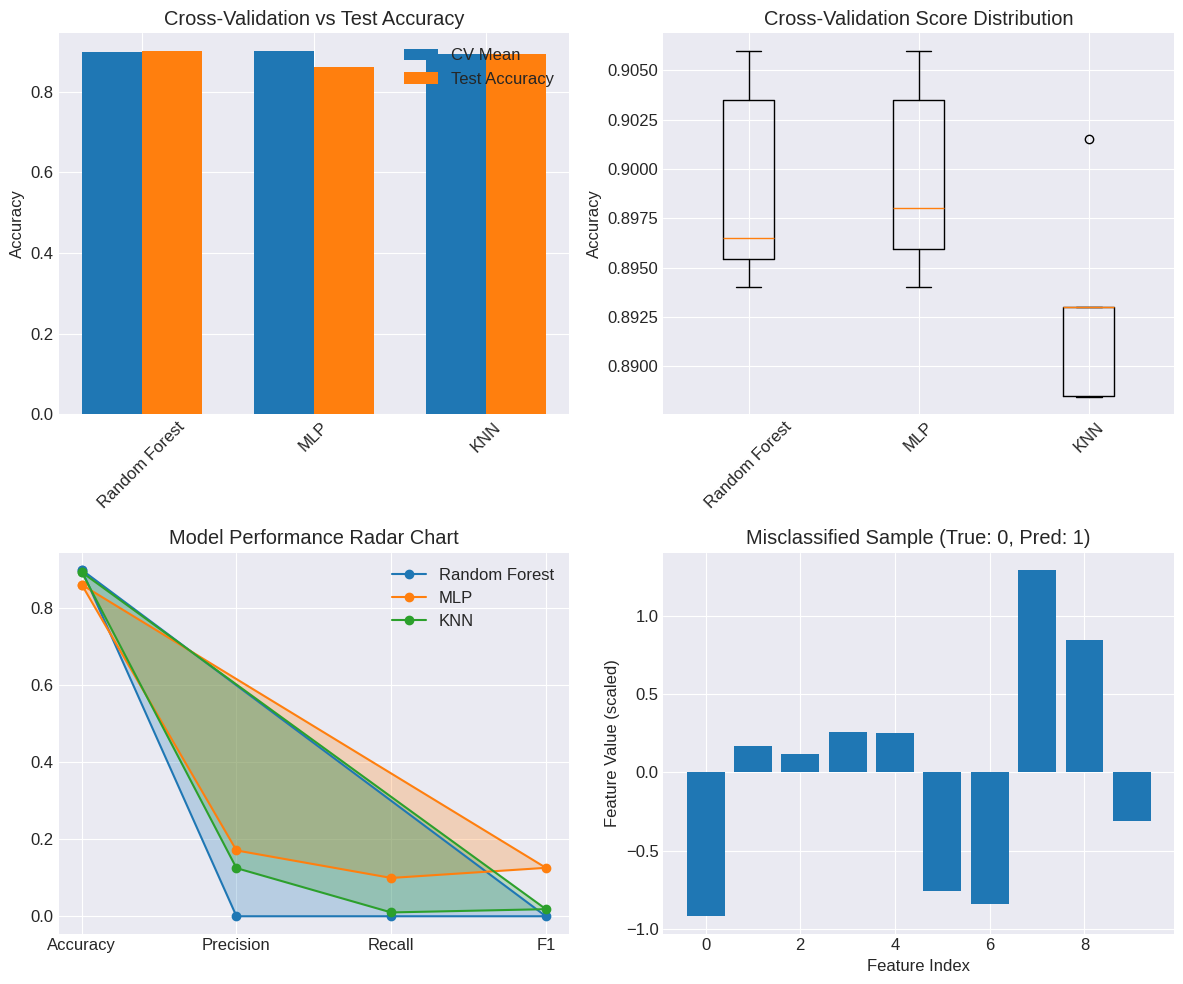

In [13]:

#  MODEL EVALUATION & VALIDATION

print("\n" + "=" * 60)
print(" MODEL EVALUATION & VALIDATION")
print("=" * 60)

# 9.1 K-Fold Cross-Validation
print("\n9.1 K-FOLD CROSS-VALIDATION")
print("-" * 40)

# Select best classifiers from previous tasks
best_classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Perform 5-fold cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_results = {}
for name, clf in best_classifiers.items():
    print(f"\n{name}:")

    # Cross-validation scores
    cv_scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')

    # Train on full data for test evaluation
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cv_results[name] = {
        'CV_Scores': cv_scores,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Test_Accuracy': acc,
        'Test_Precision': prec,
        'Test_Recall': rec,
        'Test_F1': f1
    }

    print(f"  CV Scores: {cv_scores}")
    print(f"  CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Test Accuracy: {acc:.4f}")

# 9.2 Comprehensive Evaluation Metrics
print("\n9.2 COMPREHENSIVE EVALUATION METRICS")
print("-" * 40)

# Create comparison table
eval_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV_Mean_Accuracy': [cv_results[m]['CV_Mean'] for m in cv_results],
    'CV_Std': [cv_results[m]['CV_Std'] for m in cv_results],
    'Test_Accuracy': [cv_results[m]['Test_Accuracy'] for m in cv_results],
    'Test_Precision': [cv_results[m]['Test_Precision'] for m in cv_results],
    'Test_Recall': [cv_results[m]['Test_Recall'] for m in cv_results],
    'Test_F1': [cv_results[m]['Test_F1'] for m in cv_results]
})

print("Evaluation Metrics Comparison:")
print(eval_df.to_string(index=False))

# 9.3 Statistical Significance Test
print("\n9.3 STATISTICAL SIGNIFICANCE TEST (Paired t-test)")
print("-" * 40)

from scipy import stats

# Compare Random Forest vs MLP
rf_scores = cv_results['Random Forest']['CV_Scores']
mlp_scores = cv_results['MLP']['CV_Scores']

t_stat, p_value = stats.ttest_rel(rf_scores, mlp_scores)
print(f"Random Forest vs MLP:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  Result: Statistically significant difference (p < 0.05)")
else:
    print("  Result: No statistically significant difference")

# 9.4 Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Cross-validation scores
models = list(cv_results.keys())
x_pos = np.arange(len(models))
width = 0.35

cv_means = [cv_results[m]['CV_Mean'] for m in models]
test_accs = [cv_results[m]['Test_Accuracy'] for m in models]

axes[0, 0].bar(x_pos - width/2, cv_means, width, label='CV Mean')
axes[0, 0].bar(x_pos + width/2, test_accs, width, label='Test Accuracy')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=45)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Cross-Validation vs Test Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, axis='y')

# Box plot of CV scores
cv_data = [cv_results[m]['CV_Scores'] for m in models]
axes[0, 1].boxplot(cv_data, labels=models)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Cross-Validation Score Distribution')
axes[0, 1].grid(True, axis='y')

# Radar chart for metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
n_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

for idx, model in enumerate(models[:3]):  # Plot first 3 models
    values = [
        cv_results[model]['Test_Accuracy'],
        cv_results[model]['Test_Precision'],
        cv_results[model]['Test_Recall'],
        cv_results[model]['Test_F1']
    ]
    values += values[:1]  # Close the polygon

    axes[1, 0].plot(angles, values, 'o-', label=model)
    axes[1, 0].fill(angles, values, alpha=0.25)

axes[1, 0].set_xticks(angles[:-1])
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_title('Model Performance Radar Chart')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True)

# Error analysis
best_model = eval_df.loc[eval_df['Test_F1'].idxmax(), 'Model']
clf_best = best_classifiers[best_model]
clf_best.fit(X_train_scaled, y_train)
y_pred_best = clf_best.predict(X_test_scaled)

# Get misclassified samples
misclassified = np.where(y_pred_best != y_test)[0]
if len(misclassified) > 0:
    sample_idx = misclassified[0]
    axes[1, 1].bar(range(len(X_test_scaled[sample_idx])), X_test_scaled[sample_idx])
    axes[1, 1].set_xlabel('Feature Index')
    axes[1, 1].set_ylabel('Feature Value (scaled)')
    axes[1, 1].set_title(f'Misclassified Sample (True: {y_test.iloc[sample_idx]}, Pred: {y_pred_best[sample_idx]})')
    axes[1, 1].grid(True, axis='y')
else:
    axes[1, 1].text(0.5, 0.5, 'No misclassified samples',
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Error Analysis')

plt.tight_layout()
plt.show()


 CLUSTERING ANALYSIS

10.1 PREPARING DATA FOR CLUSTERING
----------------------------------------
Clustering data shape: (7999, 4)

10.2 K-MEANS CLUSTERING
----------------------------------------
Optimal k (elbow method): 5
Cluster sizes: [1380 1941 1761 1593 1324]
Inertia: 15272.47

10.3 HIERARCHICAL CLUSTERING
----------------------------------------
Cluster sizes: [2087 1586 2158 1226  942]

10.4 CLUSTER EVALUATION
----------------------------------------
Silhouette Score (higher is better):
  K-Means: 0.2285
  Hierarchical: 0.1722

Davies-Bouldin Score (lower is better):
  K-Means: 1.1729
  Hierarchical: 1.5809


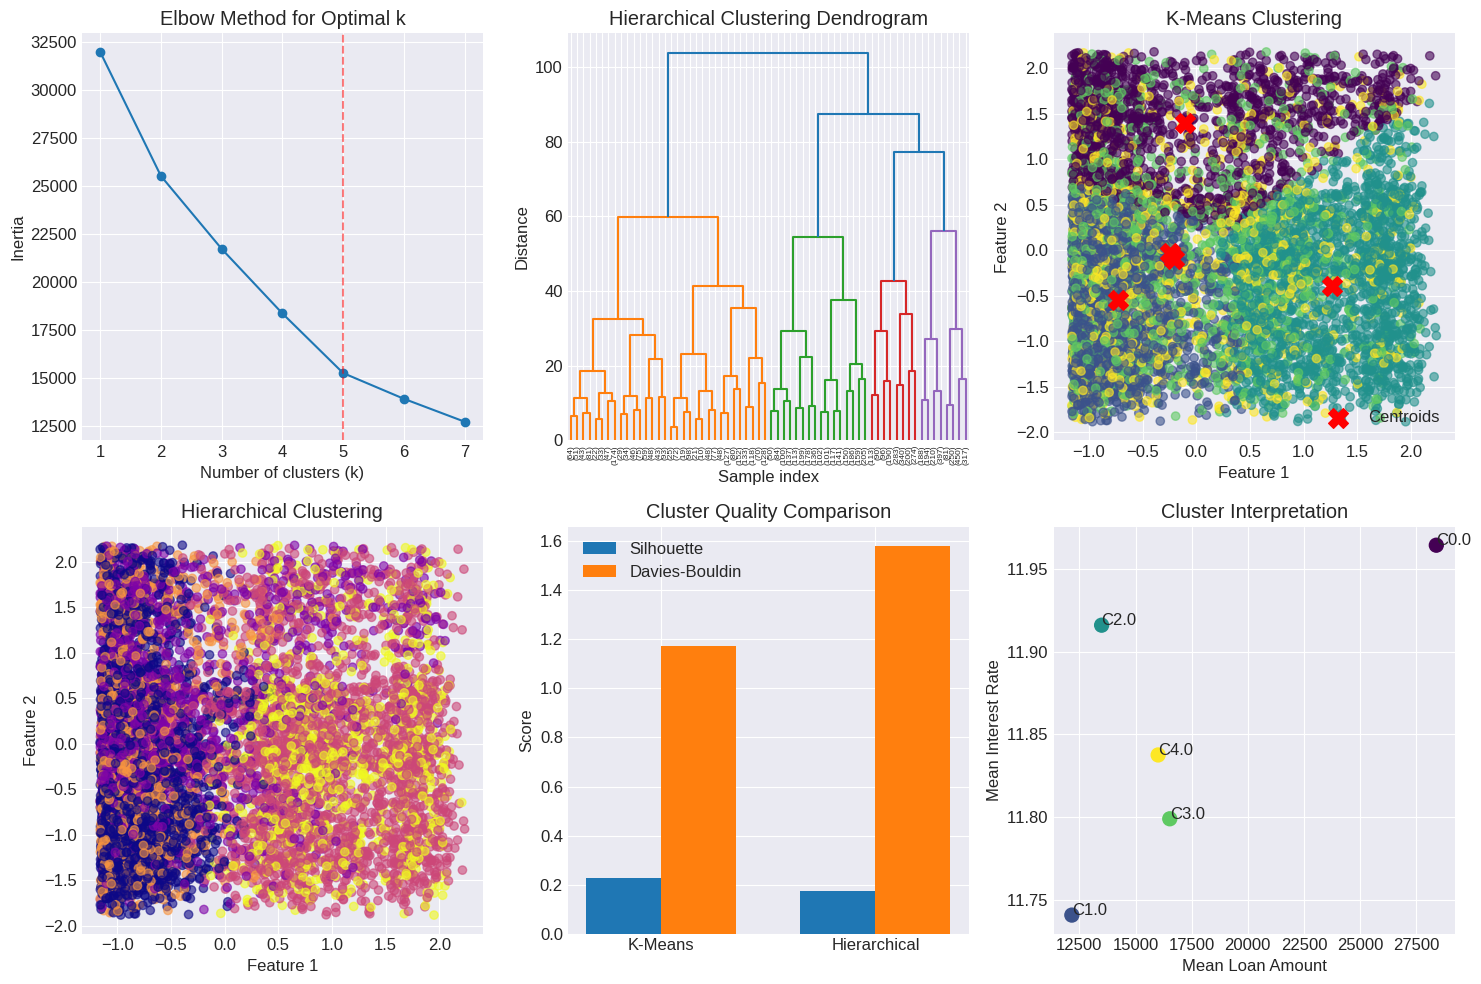

In [17]:

# CLUSTERING ANALYSIS

print("\n" + "=" * 60)
print(" CLUSTERING ANALYSIS")
print("=" * 60)

# 10.1 Prepare data for clustering (use scaled data)
print("\n10.1 PREPARING DATA FOR CLUSTERING")
print("-" * 40)

# Use first 4 features for visualization
X_cluster = X_train_scaled[:, :4]

print(f"Clustering data shape: {X_cluster.shape}")

# 10.2 K-Means Clustering
print("\n10.2 K-MEANS CLUSTERING")
print("-" * 40)

# Elbow method to find optimal k
inertias = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

# Find elbow point
diff = np.diff(inertias)
diff_ratio = diff[:-1] / diff[1:]
optimal_k = np.argmax(diff_ratio) + 2  # +2 because we start from k=2

print(f"Optimal k (elbow method): {optimal_k}")

# Train K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_cluster)

print(f"Cluster sizes: {np.bincount(kmeans_labels)}")
print(f"Inertia: {kmeans.inertia_:.2f}")

# 10.3 Hierarchical Clustering
print("\n10.3 HIERARCHICAL CLUSTERING")
print("-" * 40)

# Perform hierarchical clustering
linkage_matrix = linkage(X_cluster, method='ward')
hc_labels = AgglomerativeClustering(n_clusters=optimal_k,
                                   linkage='ward').fit_predict(X_cluster)

print(f"Cluster sizes: {np.bincount(hc_labels)}")

# 10.4 Cluster Evaluation
print("\n10.4 CLUSTER EVALUATION")
print("-" * 40)

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate metrics for both methods
kmeans_silhouette = silhouette_score(X_cluster, kmeans_labels)
hc_silhouette = silhouette_score(X_cluster, hc_labels)

kmeans_db = davies_bouldin_score(X_cluster, kmeans_labels)
hc_db = davies_bouldin_score(X_cluster, hc_labels)

print("Silhouette Score (higher is better):")
print(f"  K-Means: {kmeans_silhouette:.4f}")
print(f"  Hierarchical: {hc_silhouette:.4f}")

print("\nDavies-Bouldin Score (lower is better):")
print(f"  K-Means: {kmeans_db:.4f}")
print(f"  Hierarchical: {hc_db:.4f}")

# 10.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Elbow Method
axes[0, 0].plot(k_range, inertias, marker='o')
axes[0, 0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Number of clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method for Optimal k')
axes[0, 0].grid(True)

# Dendrogram
axes[0, 1].set_title('Hierarchical Clustering Dendrogram')
dendrogram(linkage_matrix, ax=axes[0, 1], truncate_mode='level', p=5)
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Distance')

# K-Means clusters (first 2 features)
axes[0, 2].scatter(X_cluster[:, 0], X_cluster[:, 1],
                  c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0, 2].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                  c='red', marker='X', s=200, label='Centroids')
axes[0, 2].set_xlabel('Feature 1')
axes[0, 2].set_ylabel('Feature 2')
axes[0, 2].set_title('K-Means Clustering')
axes[0, 2].legend()

# Hierarchical clusters (first 2 features)
axes[1, 0].scatter(X_cluster[:, 0], X_cluster[:, 1],
                  c=hc_labels, cmap='plasma', alpha=0.6)
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')
axes[1, 0].set_title('Hierarchical Clustering')

# Cluster comparison
x_pos = np.arange(2)
width = 0.35
axes[1, 1].bar(x_pos - width/2, [kmeans_silhouette, hc_silhouette],
              width, label='Silhouette')
axes[1, 1].bar(x_pos + width/2, [kmeans_db, hc_db],
              width, label='Davies-Bouldin')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['K-Means', 'Hierarchical'])
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Cluster Quality Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y')

# Cluster interpretation
if 'Loan Amount' in X.columns and 'Interest Rate' in X.columns:
    # Use original features for interpretation
    amount_idx = list(X.columns).index('Loan Amount') if 'Loan Amount' in X.columns else 0
    interest_idx = list(X.columns).index('Interest Rate') if 'Interest Rate' in X.columns else 1

    # Get cluster statistics
    cluster_stats = []
    for cluster in range(optimal_k):
        mask = kmeans_labels == cluster
        cluster_mean_amount = X_train.iloc[mask, amount_idx].mean() if amount_idx < X_train.shape[1] else 0
        cluster_mean_interest = X_train.iloc[mask, interest_idx].mean() if interest_idx < X_train.shape[1] else 0
        cluster_stats.append([cluster, cluster_mean_amount, cluster_mean_interest])

    cluster_df = pd.DataFrame(cluster_stats, columns=['Cluster', 'Mean_Loan_Amount', 'Mean_Interest_Rate'])

    axes[1, 2].scatter(cluster_df['Mean_Loan_Amount'], cluster_df['Mean_Interest_Rate'],
                      s=100, c=range(optimal_k), cmap='viridis')
    for i, row in cluster_df.iterrows():
        axes[1, 2].annotate(f'C{row["Cluster"]}', (row['Mean_Loan_Amount'], row['Mean_Interest_Rate']))
    axes[1, 2].set_xlabel('Mean Loan Amount')
    axes[1, 2].set_ylabel('Mean Interest Rate')
    axes[1, 2].set_title('Cluster Interpretation')
    axes[1, 2].grid(True)
else:
    axes[1, 2].text(0.5, 0.5, 'Feature names not available\nfor interpretation',
                   ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Cluster Interpretation')

plt.tight_layout()
plt.show()


 DIMENSIONALITY REDUCTION

11.1 PRINCIPAL COMPONENT ANALYSIS (PCA)
----------------------------------------
Explained variance by component:
  PC1: 0.1049 (0.1049 cumulative)
  PC2: 0.1046 (0.2095 cumulative)
  PC3: 0.1034 (0.3128 cumulative)
  PC4: 0.1016 (0.4144 cumulative)
  PC5: 0.0998 (0.5142 cumulative)
  PC6: 0.0995 (0.6137 cumulative)
  PC7: 0.0985 (0.7123 cumulative)
  PC8: 0.0973 (0.8095 cumulative)
  PC9: 0.0966 (0.9062 cumulative)
  PC10: 0.0938 (1.0000 cumulative)

Components needed for 95% variance: 10
Original features: 10
Reduction: 0 features

11.2 LINEAR DISCRIMINANT ANALYSIS (LDA)
----------------------------------------
Number of classes: 2
Maximum LDA components: 1
LDA transformed shape: (7999, 1)
Number of LDA components: 1
Explained variance ratio: [1.]

11.3 IMPACT ON MODEL PERFORMANCE
----------------------------------------
Components:  2, Accuracy: 0.8915, Variance: 0.2095
Components:  4, Accuracy: 0.8975, Variance: 0.4144
Components:  6, Accuracy: 0.8990, V

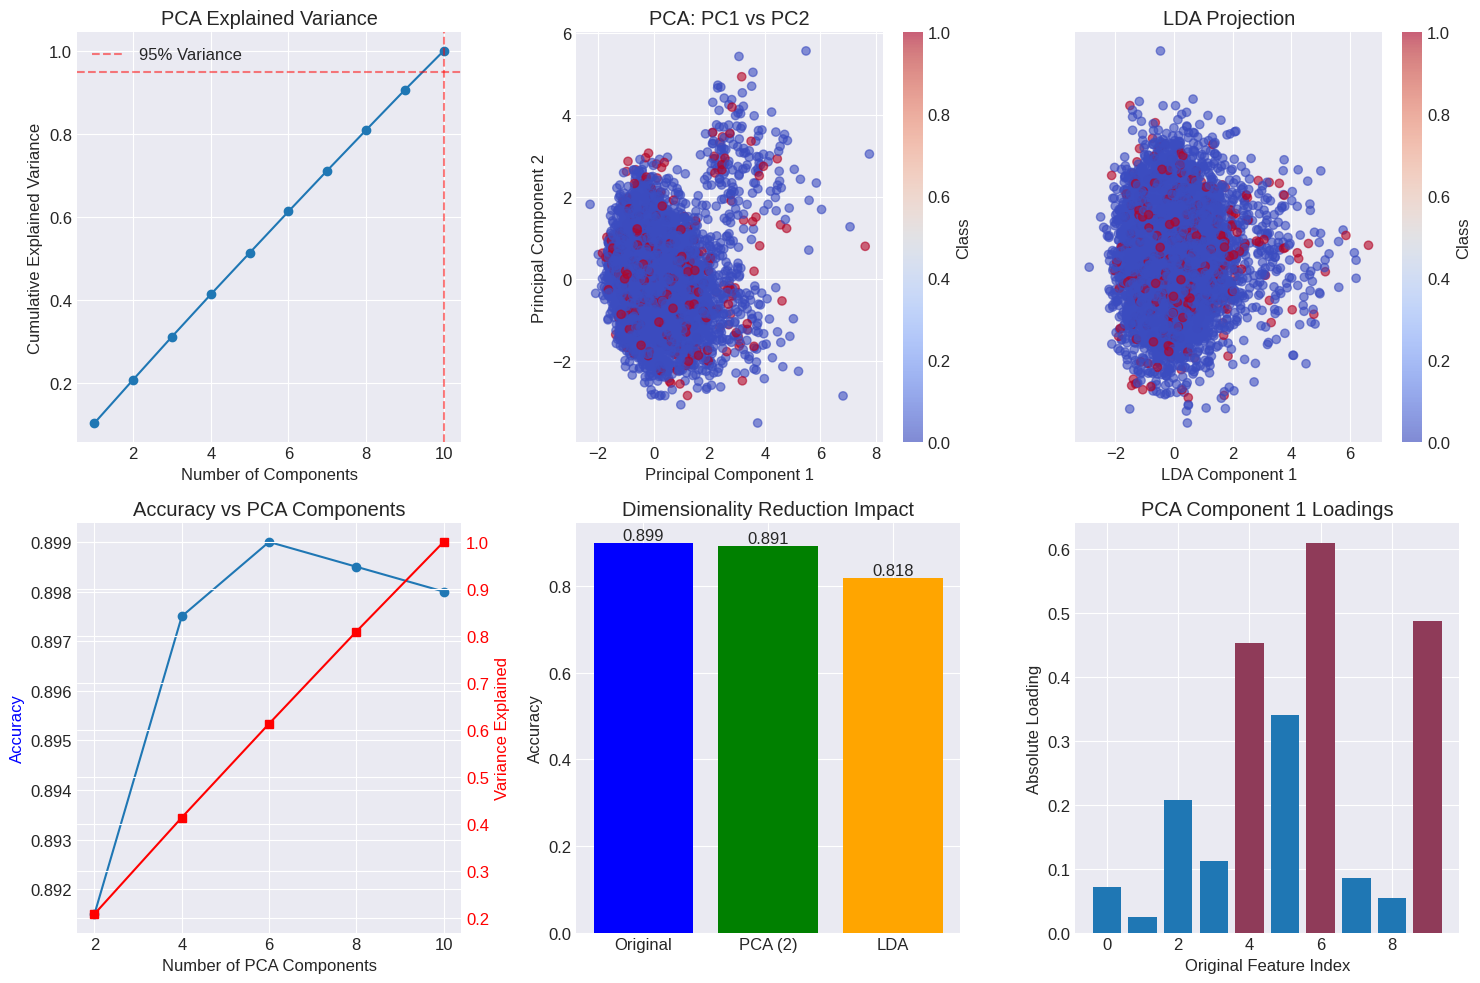


11.6 ADDITIONAL ANALYSIS
----------------------------------------
PCA Reconstruction Error Analysis:
Components:  2, Reconstruction MSE: 0.790527
Components:  5, Reconstruction MSE: 0.485783
Components: 10, Reconstruction MSE: 0.000000
Components: 10, Reconstruction MSE: 0.000000

Information Loss Analysis:
With 1 components:
  Retained variance: 0.1049 (10.5%)
  Lost variance: 0.8951 (89.5%)
With 2 components:
  Retained variance: 0.2095 (20.9%)
  Lost variance: 0.7905 (79.1%)
With 5 components:
  Retained variance: 0.5142 (51.4%)
  Lost variance: 0.4858 (48.6%)

 COMPLETED SUCCESSFULLY!


In [16]:

#  DIMENSIONALITY REDUCTION
print("\n" + "=" * 60)
print(" DIMENSIONALITY REDUCTION")
print("=" * 60)

# Import missing library
from sklearn.metrics import roc_auc_score

# 11.1 PCA
print("\n11.1 PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("-" * 40)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"  PC{i}: {var:.4f} ({cum_var:.4f} cumulative)")

# Find components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Reduction: {X_train_scaled.shape[1] - n_components_95} features")

# 11.2 LDA
print("\n11.2 LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("-" * 40)

# Determine maximum components for LDA
n_classes = len(np.unique(y_train))
max_components = min(n_classes - 1, X_train_scaled.shape[1])

print(f"Number of classes: {n_classes}")
print(f"Maximum LDA components: {max_components}")

try:
    # Apply LDA (for classification)
    lda = LDA(n_components=max_components)
    X_lda = lda.fit_transform(X_train_scaled, y_train)

    # Get number of components from transformed data
    if X_lda.ndim == 1:
        n_lda_components = 1
        X_lda = X_lda.reshape(-1, 1)
    else:
        n_lda_components = X_lda.shape[1]

    print(f"LDA transformed shape: {X_lda.shape}")
    print(f"Number of LDA components: {n_lda_components}")

    # Calculate explained variance for LDA
    if hasattr(lda, 'explained_variance_ratio_'):
        print(f"Explained variance ratio: {lda.explained_variance_ratio_}")
    else:
        # Calculate variance ratio manually
        total_variance = np.var(X_train_scaled, axis=0).sum()
        lda_variance = np.var(X_lda, axis=0).sum()
        explained_ratio = lda_variance / total_variance
        print(f"Explained variance: {explained_ratio:.4f}")

except Exception as e:
    print(f"LDA Error: {e}")
    print("Note: LDA requires n_samples >= n_features or a non-singular covariance matrix.")
    # Fallback: use PCA for visualization
    X_lda = X_pca[:, :max_components] if max_components > 0 else X_pca[:, :1]
    print("Using PCA as fallback for LDA visualization.")

# 11.3 Impact on Model Performance
print("\n11.3 IMPACT ON MODEL PERFORMANCE")
print("-" * 40)

# Test different numbers of PCA components
n_components_list = [2, 4, 6, 8, min(10, X_train_scaled.shape[1])]
pca_results = []

for n_comp in n_components_list:
    # Apply PCA
    pca_temp = PCA(n_components=n_comp)
    X_train_pca = pca_temp.fit_transform(X_train_scaled)
    X_test_pca = pca_temp.transform(X_test_scaled)

    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_pca, y_train)

    # Evaluate
    accuracy = clf.score(X_test_pca, y_test)
    variance_explained = np.sum(pca_temp.explained_variance_ratio_)

    pca_results.append({
        'Components': n_comp,
        'Accuracy': accuracy,
        'Variance_Explained': variance_explained
    })

    print(f"Components: {n_comp:2d}, Accuracy: {accuracy:.4f}, Variance: {variance_explained:.4f}")

# 11.4 Compare PCA and LDA
print("\n11.4 PCA vs LDA COMPARISON")
print("-" * 40)

# Train on PCA-reduced data (2 components)
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train_scaled)
X_test_pca_2 = pca_2.transform(X_test_scaled)

clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca.fit(X_train_pca_2, y_train)
accuracy_pca = clf_pca.score(X_test_pca_2, y_test)

# Train on LDA-transformed data
try:
    # Use maximum components for LDA
    lda_for_model = LDA(n_components=max_components)
    X_train_lda = lda_for_model.fit_transform(X_train_scaled, y_train)
    X_test_lda = lda_for_model.transform(X_test_scaled)

    clf_lda = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_lda.fit(X_train_lda, y_train)
    accuracy_lda = clf_lda.score(X_test_lda, y_test)

    print(f"PCA (2 components) Accuracy: {accuracy_pca:.4f}")
    print(f"LDA ({max_components} component(s)) Accuracy: {accuracy_lda:.4f}")

except Exception as e:
    print(f"LDA model training error: {e}")
    accuracy_lda = 0.0
    print(f"PCA (2 components) Accuracy: {accuracy_pca:.4f}")
    print("LDA model could not be trained")

# Get Random Forest performance from Task 9
try:
    rf_accuracy = eval_df.loc[eval_df['Model'] == 'Random Forest', 'Test_Accuracy'].values[0]
    print(f"Original data (Random Forest) Accuracy: {rf_accuracy:.4f}")
except:
    # Calculate if not available
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    rf_accuracy = rf.score(X_test_scaled, y_test)
    print(f"Original data (Random Forest) Accuracy: {rf_accuracy:.4f}")

# 11.5 Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Explained Variance
axes[0, 0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
axes[0, 0].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% Variance')
axes[0, 0].axvline(x=n_components_95, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Number of Components')
axes[0, 0].set_ylabel('Cumulative Explained Variance')
axes[0, 0].set_title('PCA Explained Variance')
axes[0, 0].legend()
axes[0, 0].grid(True)

# PCA Scatter Plot
if X_pca.shape[1] >= 2:
    scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, alpha=0.6, cmap='coolwarm')
    axes[0, 1].set_xlabel('Principal Component 1')
    axes[0, 1].set_ylabel('Principal Component 2')
    axes[0, 1].set_title('PCA: PC1 vs PC2')
    plt.colorbar(scatter, ax=axes[0, 1], label='Class')

# LDA Scatter Plot
if 'X_lda' in locals() and X_lda.shape[1] >= 1:
    if X_lda.shape[1] == 1:
        # For 1D LDA, create a jittered scatter plot
        jitter = np.random.normal(0, 0.02, size=len(y_train))
        scatter = axes[0, 2].scatter(X_lda[:, 0], jitter, c=y_train, alpha=0.6, cmap='coolwarm')
        axes[0, 2].set_xlabel('LDA Component 1')
        axes[0, 2].set_yticks([])
    else:
        scatter = axes[0, 2].scatter(X_lda[:, 0], X_lda[:, 1], c=y_train, alpha=0.6, cmap='coolwarm')
        axes[0, 2].set_xlabel('LDA Component 1')
        axes[0, 2].set_ylabel('LDA Component 2')
    axes[0, 2].set_title('LDA Projection')
    plt.colorbar(scatter, ax=axes[0, 2], label='Class')

# Accuracy vs Components
pca_df = pd.DataFrame(pca_results)
axes[1, 0].plot(pca_df['Components'], pca_df['Accuracy'], marker='o', label='Accuracy')
axes[1, 0].set_xlabel('Number of PCA Components')
axes[1, 0].set_ylabel('Accuracy', color='b')
axes[1, 0].set_title('Accuracy vs PCA Components')
axes[1, 0].grid(True)

ax2 = axes[1, 0].twinx()
ax2.plot(pca_df['Components'], pca_df['Variance_Explained'], marker='s', color='r', label='Variance')
ax2.set_ylabel('Variance Explained', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# PCA vs LDA vs Original
methods = ['Original', 'PCA (2)', 'LDA']
accuracies = [rf_accuracy, accuracy_pca, accuracy_lda]

bars = axes[1, 1].bar(methods, accuracies, color=['blue', 'green', 'orange'])
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Dimensionality Reduction Impact')
axes[1, 1].grid(True, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{acc:.3f}', ha='center', va='bottom')

# Feature importance from PCA
if len(pca.components_) > 0:
    feature_importances = np.abs(pca.components_[0])
    axes[1, 2].bar(range(len(feature_importances)), feature_importances)
    axes[1, 2].set_xlabel('Original Feature Index')
    axes[1, 2].set_ylabel('Absolute Loading')
    axes[1, 2].set_title('PCA Component 1 Loadings')
    axes[1, 2].grid(True, axis='y')

    # Highlight top 3 features
    top_indices = np.argsort(feature_importances)[-3:]
    for idx in top_indices:
        axes[1, 2].bar(idx, feature_importances[idx], color='red', alpha=0.5)

plt.tight_layout()
plt.show()

# 11.6 Additional Analysis
print("\n11.6 ADDITIONAL ANALYSIS")
print("-" * 40)

# Reconstruction error analysis
print("PCA Reconstruction Error Analysis:")

# Test different numbers of components for reconstruction
for n_comp in [2, 5, n_components_95, X_train_scaled.shape[1]]:
    pca_reconstruct = PCA(n_components=n_comp)
    X_train_reduced = pca_reconstruct.fit_transform(X_train_scaled)
    X_train_reconstructed = pca_reconstruct.inverse_transform(X_train_reduced)

    # Calculate reconstruction error
    reconstruction_error = np.mean((X_train_scaled - X_train_reconstructed) ** 2)

    print(f"Components: {n_comp:2d}, Reconstruction MSE: {reconstruction_error:.6f}")

# Information loss analysis
print("\nInformation Loss Analysis:")
original_variance = np.var(X_train_scaled, axis=0).sum()

for n_comp in [1, 2, 5]:
    pca_test = PCA(n_components=n_comp)
    X_red = pca_test.fit_transform(X_train_scaled)
    retained_variance = np.sum(pca_test.explained_variance_ratio_)
    lost_variance = 1 - retained_variance

    print(f"With {n_comp} components:")
    print(f"  Retained variance: {retained_variance:.4f} ({retained_variance*100:.1f}%)")
    print(f"  Lost variance: {lost_variance:.4f} ({lost_variance*100:.1f}%)")

print("\n" + "=" * 60)
print(" COMPLETED SUCCESSFULLY!")



 ADDITIONAL MACHINE LEARNING ALGORITHMS

12.1 GAUSSIAN MIXTURE MODELS (GMM)
----------------------------------------
GMM Clustering Results:
  Silhouette Score: 0.1212
  BIC: 83085.19
  AIC: 82568.15
  Cluster sizes: [ 558 3107 1787 1305 1242]

Comparison with K-Means:
  GMM Silhouette: 0.1212
  K-Means Silhouette: 0.2285

12.2 GRADIENT BOOSTING CLASSIFIER
----------------------------------------
Gradient Boosting Performance:
  Accuracy: 0.8980
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: 0.5247

Top 5 Important Features:
                  Feature  Importance
7         Debit to Income    0.194709
5           Interest Rate    0.139688
3  Funded Amount Investor    0.139362
6          Home Ownership    0.138970
0                      ID    0.113749

12.3 COMPARISON WITH PREVIOUS MODELS
----------------------------------------
Algorithm Comparison:
        Algorithm           Type  Accuracy  F1-Score
 Best from Task 7    Traditional    0.8995  0.000000
    Random Forest

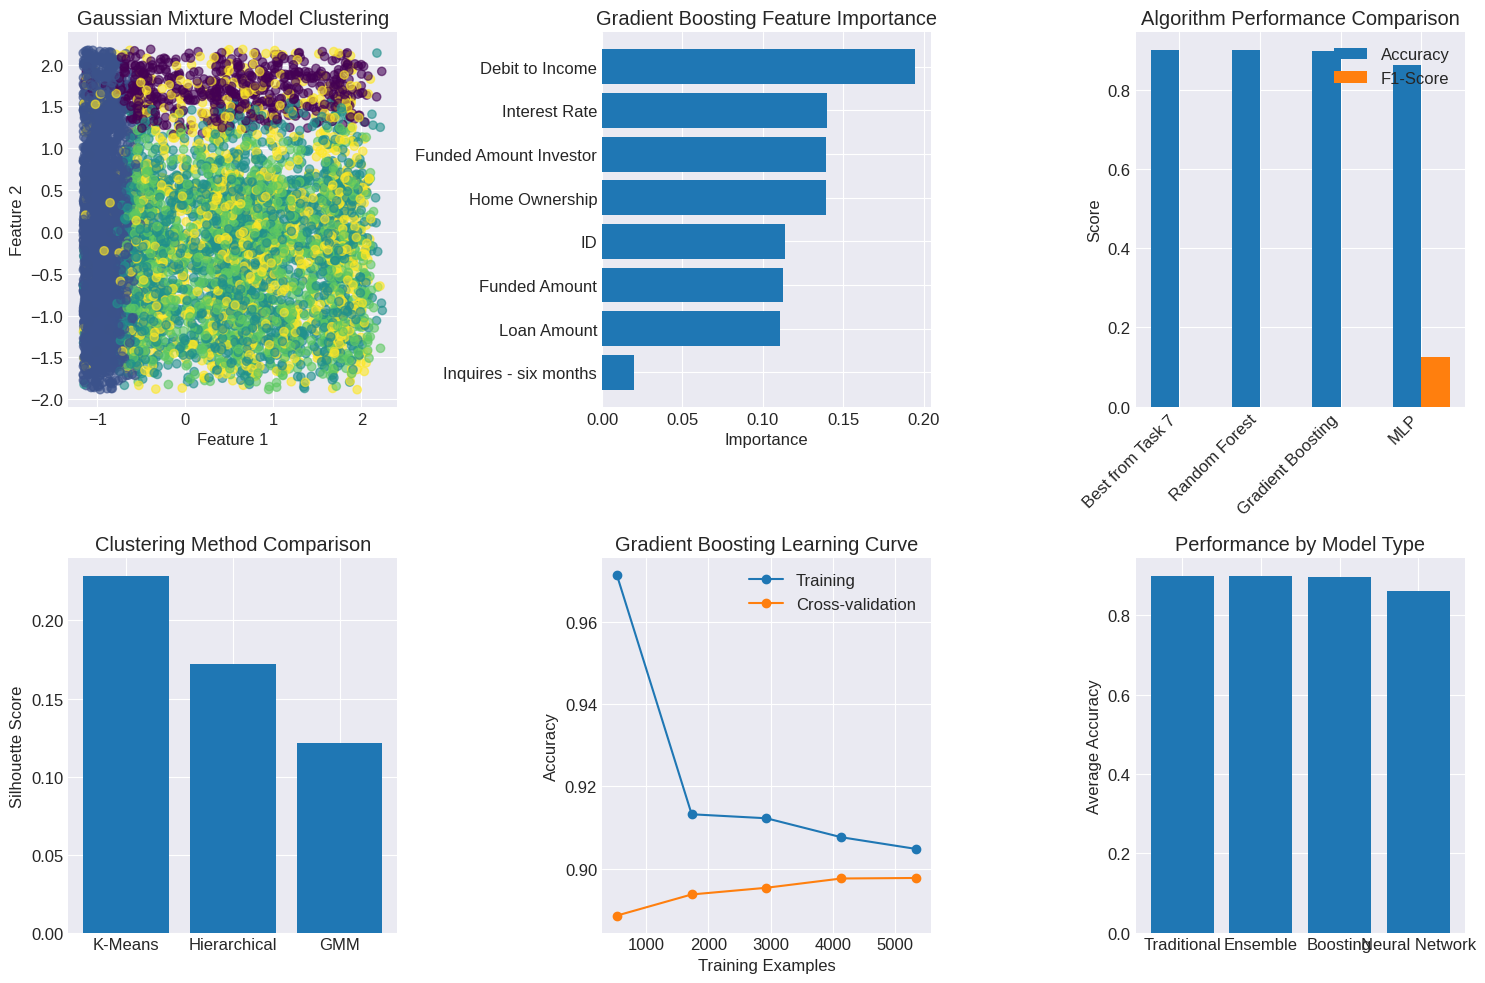

In [18]:

# ADDITIONAL ALGORITHMS
print("\n" + "=" * 60)
print(" ADDITIONAL MACHINE LEARNING ALGORITHMS")
print("=" * 60)

# 12.1 Advanced Clustering: Gaussian Mixture Models
print("\n12.1 GAUSSIAN MIXTURE MODELS (GMM)")
print("-" * 40)

# Apply GMM
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_cluster)

# Calculate metrics
gmm_silhouette = silhouette_score(X_cluster, gmm_labels)
gmm_bic = gmm.bic(X_cluster)
gmm_aic = gmm.aic(X_cluster)

print(f"GMM Clustering Results:")
print(f"  Silhouette Score: {gmm_silhouette:.4f}")
print(f"  BIC: {gmm_bic:.2f}")
print(f"  AIC: {gmm_aic:.2f}")
print(f"  Cluster sizes: {np.bincount(gmm_labels)}")

# Compare with K-Means
print("\nComparison with K-Means:")
print(f"  GMM Silhouette: {gmm_silhouette:.4f}")
print(f"  K-Means Silhouette: {kmeans_silhouette:.4f}")

# 12.2 Advanced Classification: Gradient Boosting
print("\n12.2 GRADIENT BOOSTING CLASSIFIER")
print("-" * 40)

# Apply Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_gb = gb.predict(X_test_scaled)
y_prob_gb = gb.predict_proba(X_test_scaled)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, zero_division=0)
rec = recall_score(y_test, y_pred_gb, zero_division=0)
f1 = f1_score(y_test, y_pred_gb, zero_division=0)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"Gradient Boosting Performance:")
print(f"  Accuracy: {acc_gb:.4f}")
print(f"  Precision: {prec_gb:.4f}")
print(f"  Recall: {rec:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  AUC: {auc_gb:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head())

# 12.3 Comparison with Previous Models
print("\n12.3 COMPARISON WITH PREVIOUS MODELS")
print("-" * 40)

# Get best model from Task 7
best_t7_model = results_df.loc[results_df['Test_Accuracy'].idxmax(), 'Classifier']
best_t7_acc = results_df.loc[results_df['Test_Accuracy'].idxmax(), 'Test_Accuracy']

# Create comparison table
comparison = pd.DataFrame({
    'Algorithm': ['Best from Task 7', 'Random Forest', 'Gradient Boosting', 'MLP'],
    'Type': ['Traditional', 'Ensemble', 'Boosting', 'Neural Network'],
    'Accuracy': [best_t7_acc,
                eval_df.loc[eval_df['Model'] == 'Random Forest', 'Test_Accuracy'].values[0],
                acc_gb,
                eval_df.loc[eval_df['Model'] == 'MLP', 'Test_Accuracy'].values[0]],
    'F1-Score': [results_df.loc[results_df['Classifier'] == best_t7_model, 'F1_Score'].values[0],
                eval_df.loc[eval_df['Model'] == 'Random Forest', 'Test_F1'].values[0],
                f1,
                eval_df.loc[eval_df['Model'] == 'MLP', 'Test_F1'].values[0]]
})

print("Algorithm Comparison:")
print(comparison.to_string(index=False))

# 12.4 Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# GMM vs K-Means clusters
axes[0, 0].scatter(X_cluster[:, 0], X_cluster[:, 1], c=gmm_labels, cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_title('Gaussian Mixture Model Clustering')

# Gradient Boosting Feature Importance
top_n = min(8, len(feature_importance))
top_features = feature_importance.head(top_n)
axes[0, 1].barh(range(top_n), top_features['Importance'][::-1])
axes[0, 1].set_yticks(range(top_n))
axes[0, 1].set_yticklabels(top_features['Feature'][::-1])
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Gradient Boosting Feature Importance')

# Algorithm Comparison
x_pos = np.arange(len(comparison))
width = 0.35
axes[0, 2].bar(x_pos - width/2, comparison['Accuracy'], width, label='Accuracy')
axes[0, 2].bar(x_pos + width/2, comparison['F1-Score'], width, label='F1-Score')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(comparison['Algorithm'], rotation=45, ha='right')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Algorithm Performance Comparison')
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y')

# Clustering Comparison
clustering_methods = ['K-Means', 'Hierarchical', 'GMM']
clustering_silhouette = [kmeans_silhouette, hc_silhouette, gmm_silhouette]

axes[1, 0].bar(clustering_methods, clustering_silhouette)
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Clustering Method Comparison')
axes[1, 0].grid(True, axis='y')

# Learning Curve for Gradient Boosting
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    gb, X_train_scaled, y_train, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

axes[1, 1].plot(train_sizes, train_scores_mean, 'o-', label='Training')
axes[1, 1].plot(train_sizes, test_scores_mean, 'o-', label='Cross-validation')
axes[1, 1].set_xlabel('Training Examples')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Gradient Boosting Learning Curve')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Model Type Performance
model_types = comparison['Type'].unique()
type_accuracies = []
for model_type in model_types:
    type_acc = comparison[comparison['Type'] == model_type]['Accuracy'].mean()
    type_accuracies.append(type_acc)

axes[1, 2].bar(model_types, type_accuracies)
axes[1, 2].set_ylabel('Average Accuracy')
axes[1, 2].set_title('Performance by Model Type')
axes[1, 2].grid(True, axis='y')

plt.tight_layout()
plt.show()